# Köppel-Martin SPE10 layer-20 no-fracture CG/PINN flux reconstruction and MRST/TPFA transport control

This notebook is the matrix-only, no-fracture counterpart of the Köppel-Martin boundary-pressure setup using a heterogeneous SPE10 permeability field. It keeps the three transport flux choices used in the comparison:

- raw CG flux `v_h` from a P1 pressure solve with DG0/cellwise permeability,
- CG+PINN reconstructed flux `v_theta`,
- MRST/TPFA finite-volume flux.

The pressure problem uses `p=1` on `x=0`, `p=4` on `x=1`, homogeneous Neumann on `y=0` and `y=1`, zero source, and the exported SPE10 layer-20 permeability `kappa_cell` as a DG0 coefficient.

Transport uses `S=1` on the inflow boundary at `x=1`, with outflow at `x=0` and no-flow top/bottom.


In [1]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy.io import loadmat
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

try:
    import torch
    import torch.nn as nn
    from tqdm.auto import tqdm
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    torch = None
    nn = None
    TORCH_AVAILABLE = False

    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

np.random.seed(1234)
if TORCH_AVAILABLE:
    torch.manual_seed(1234)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "numpy"

REF = 5
N_BULK = 2 ** (REF + 1)
# Raw-CG trace convention on rectangular transport/MRST faces:
#   "average"   : two-sided average on internal faces; one-sided on boundaries.
#   "geometric" : previous one-sided locate_structured_triangles() convention.
CG_INTERFACE_FLUX_MODE = "average"
if CG_INTERFACE_FLUX_MODE not in {"average", "geometric"}:
    raise ValueError("CG_INTERFACE_FLUX_MODE must be 'average' or 'geometric'.")
DATA_FILE = pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64.mat")
if not DATA_FILE.exists():
    matches = sorted(pathlib.Path.cwd().glob("**/case3_ecmor/case3_mrst_export_spe10_L20_64.mat"))
    DATA_FILE = matches[0] if matches else DATA_FILE
if not DATA_FILE.exists():
    raise FileNotFoundError("Could not find case3_mrst_export_spe10_L20_64.mat from the notebook directory or repository root.")

mrst = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)


def _arr(key, dtype=float):
    if key not in mrst:
        raise KeyError(f"Missing MRST field {key!r}")
    return np.asarray(mrst[key], dtype=dtype)


def _meta_float(key, default=np.nan):
    if key not in mrst:
        return float(default)
    values = np.asarray(mrst[key]).reshape(-1)
    return float(values[0]) if values.size else float(default)

xc_matrix = _arr("xc_matrix", float)
p_matrix_mrst = _arr("p_matrix", float).reshape(-1)
face_neighbors = _arr("face_neighbors", np.int64)
face_flux_mrst = _arr("face_flux", float).reshape(-1)
face_centroid = _arr("face_centroid", float)
face_normal = _arr("face_normal", float)
face_len = _arr("face_len", float).reshape(-1)
face_p1 = _arr("face_p1", float)
face_p2 = _arr("face_p2", float)
face_is_boundary = _arr("face_is_boundary", bool).reshape(-1) if "face_is_boundary" in mrst else np.any(face_neighbors == 0, axis=1)
kappa_cell_mrst = _arr("kappa_cell", float).reshape(-1) if "kappa_cell" in mrst else None

nx, ny = np.asarray(mrst.get("meta_celldim", [N_BULK, N_BULK]), dtype=int).reshape(-1)
physdim = np.asarray(mrst.get("meta_physdim", [1.0, 1.0]), dtype=float).reshape(-1)
phi_matrix = _meta_float("meta_phi_matrix", 1.0)
PV_matrix = _meta_float("meta_PV_matrix", _meta_float("meta_PV", phi_matrix * float(np.prod(physdim))))
Q_water = _meta_float("meta_Q_water", _meta_float("meta_Q_in", np.nan))
CFL = _meta_float("meta_CFL", 0.45)
FPRIME_MAX = _meta_float("meta_FPRIME_MAX", 2.0)
SPE10_LAYER = _meta_float("meta_layer", 20.0)
SPE10_CONTRAST = _meta_float("meta_contrast", np.nan)

xmin, ymin = 0.0, 0.0
xmax, ymax = float(physdim[0]), float(physdim[1])
hx = physdim[0] / nx
hy = physdim[1] / ny
h_est = min(hx, hy)
ncell = int(xc_matrix.shape[0])
cell_area = np.full(ncell, float(np.prod(physdim)) / ncell, dtype=float)
cell_pv = phi_matrix * cell_area

transport_cases = []
if "sw_matrix_pvi03" in mrst:
    transport_cases.append(("PVI0.3", "sw_matrix_pvi03", "sw_matrix_pvi03_matched", _meta_float("meta_T_pvi03"), 0.3))
if "sw_matrix_pvi05" in mrst:
    transport_cases.append(("PVI0.5", "sw_matrix_pvi05", "sw_matrix_pvi05_matched", _meta_float("meta_T_pvi05"), 0.5))
if not transport_cases:
    raise KeyError("Tanh MRST export must contain sw_matrix_pvi03 and/or sw_matrix_pvi05.")

TRANSPORT_CASE_KEY = transport_cases[0][0]

print(f"Loaded {DATA_FILE}")
print(f"Matrix grid: {nx} x {ny}, cells={ncell}, faces={len(face_flux_mrst)}")
print(f"SPE10 layer={SPE10_LAYER:.0f}, contrast={SPE10_CONTRAST:.6g}, PV={PV_matrix:.8e}, Q_water={Q_water:.8e}, CFL={CFL:.3f}")
print("Available transport snapshots:")
for key, sw_key, _, tfinal, pvi in transport_cases:
    sw = _arr(sw_key, float).reshape(-1)
    print(f"  {key:<7} T={tfinal:.8e}, PVI={pvi:.6f}, S=[{np.nanmin(sw):.3e}, {np.nanmax(sw):.3e}]")


Loaded case3_ecmor/case3_mrst_export_spe10_L20_64.mat
Matrix grid: 64 x 64, cells=4096, faces=8320
SPE10 layer=20, contrast=101803, PV=1.00000000e+00, Q_water=5.08451201e+00, CFL=0.450
Available transport snapshots:
  PVI0.3  T=5.90027125e-02, PVI=0.300000, S=[0.000e+00, 9.973e-01]
  PVI0.5  T=9.83378541e-02, PVI=0.500000, S=[0.000e+00, 9.983e-01]


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CG pressure p_h range: [1.019915, 3.998662]
MRST pressure p_FV range: [1.018205, 3.998836]
Source integral sum_K int_K f dx = +0.00000000e+00
MRST pressure comparison: mean|p_h-p_FV|=6.013e-03, rmse=8.818e-03, max|p_h-p_FV|=7.529e-02
DG0 permeability kappa: min=4.019840e-03, max=4.092313e+02, contrast=1.018029e+05


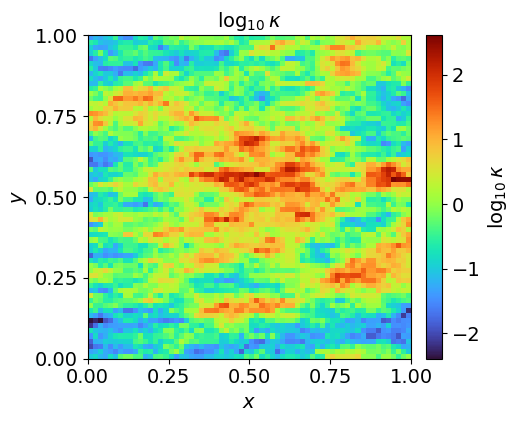

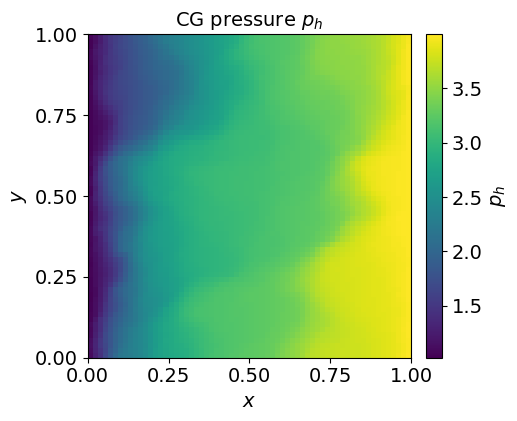

CG pressure-gradient range: dpx=[+1.712790e-01, +2.151119e+01], dpy=[-1.700657e+01, +1.598581e+01]


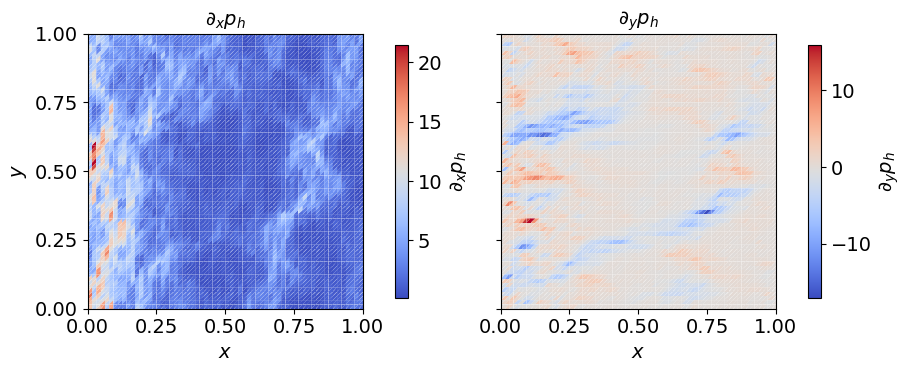

In [2]:
# SPE10/DG0-permeability CG pressure and Darcy flux.
kappa_cell_dg0 = np.asarray(kappa_cell_mrst, dtype=float).reshape(-1) if kappa_cell_mrst is not None else _arr("kappa_cell", float).reshape(-1)
if kappa_cell_dg0.size != ncell:
    raise ValueError(f"Expected one DG0 permeability value per cell ({ncell}), got {kappa_cell_dg0.size}.")


def rect_cell_ids_from_points(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    return iy * nx + ix


def kappa_numpy(points):
    return kappa_cell_dg0[rect_cell_ids_from_points(points)]


def f_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return np.zeros(pts.shape[0], dtype=float)


def top_outward_flux_numpy(x):
    x = np.asarray(x, dtype=float)
    return np.zeros_like(x, dtype=float)


def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1.0e-30)


def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )


# Structured P1 FEM solve on the same rectangular grid used by the MRST export.
x_nodes = np.linspace(xmin, xmax, nx + 1)
y_nodes = np.linspace(ymin, ymax, ny + 1)
Xn, Yn = np.meshgrid(x_nodes, y_nodes, indexing="xy")
fem_nodes = np.column_stack([Xn.ravel(), Yn.ravel()])
n_nodes = fem_nodes.shape[0]


def _nid(i, j):
    return j * (nx + 1) + i

triangles = []
for j in range(ny):
    for i in range(nx):
        ll = _nid(i, j)
        lr = _nid(i + 1, j)
        ul = _nid(i, j + 1)
        ur = _nid(i + 1, j + 1)
        triangles.append([ll, lr, ur])
        triangles.append([ll, ur, ul])
triangles = np.asarray(triangles, dtype=np.int64)


def _tri_area_grads(coords):
    x = coords[:, 0]
    y = coords[:, 1]
    twice_area = (x[1] - x[0]) * (y[2] - y[0]) - (x[2] - x[0]) * (y[1] - y[0])
    area = 0.5 * abs(twice_area)
    grads = np.empty((3, 2), dtype=float)
    grads[0] = np.array([y[1] - y[2], x[2] - x[1]]) / twice_area
    grads[1] = np.array([y[2] - y[0], x[0] - x[2]]) / twice_area
    grads[2] = np.array([y[0] - y[1], x[1] - x[0]]) / twice_area
    return area, grads

# Dunavant degree-5 quadrature; weights sum to one on the reference triangle.
_TRI_BARY = np.array([
    [1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0],
    [0.059715871789770, 0.470142064105115, 0.470142064105115],
    [0.470142064105115, 0.059715871789770, 0.470142064105115],
    [0.470142064105115, 0.470142064105115, 0.059715871789770],
    [0.797426985353087, 0.101286507323456, 0.101286507323456],
    [0.101286507323456, 0.797426985353087, 0.101286507323456],
    [0.101286507323456, 0.101286507323456, 0.797426985353087],
], dtype=float)
_TRI_W = np.array([
    0.225000000000000,
    0.132394152788506,
    0.132394152788506,
    0.132394152788506,
    0.125939180544827,
    0.125939180544827,
    0.125939180544827,
], dtype=float)

A = lil_matrix((n_nodes, n_nodes), dtype=float)
b = np.zeros(n_nodes, dtype=float)
tri_areas = np.empty(len(triangles), dtype=float)
tri_grads = np.empty((len(triangles), 3, 2), dtype=float)

for tid, tri in enumerate(triangles):
    coords = fem_nodes[tri]
    area, grads = _tri_area_grads(coords)
    tri_areas[tid] = area
    tri_grads[tid] = grads
    rect_id = tid // 2
    k_elem = float(kappa_cell_dg0[rect_id])
    for a in range(3):
        ia = tri[a]
        for c in range(3):
            ic = tri[c]
            A[ia, ic] += area * k_elem * float(np.dot(grads[a], grads[c]))

left_nodes = np.isclose(fem_nodes[:, 0], xmin, atol=1.0e-14)
right_nodes = np.isclose(fem_nodes[:, 0], xmax, atol=1.0e-14)
dirichlet = left_nodes | right_nodes
p_dirichlet = np.zeros(n_nodes, dtype=float)
p_dirichlet[left_nodes] = 1.0
p_dirichlet[right_nodes] = 4.0

A = A.tolil()
b -= A[:, dirichlet].dot(p_dirichlet[dirichlet])
for idx in np.flatnonzero(dirichlet):
    A.rows[idx] = [int(idx)]
    A.data[idx] = [1.0]
for idx in np.flatnonzero(dirichlet):
    A[:, idx] = 0.0
    A[idx, idx] = 1.0
    b[idx] = p_dirichlet[idx]

p_nodes = np.asarray(spsolve(A.tocsr(), b), dtype=float)
tri_grad_p = np.einsum("ti,tij->tj", p_nodes[triangles], tri_grads)


def locate_structured_triangles(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    tx = (pts[:, 0] - (xmin + ix * hx)) / hx
    ty = (pts[:, 1] - (ymin + iy * hy)) / hy
    tx = np.clip(tx, 0.0, 1.0)
    ty = np.clip(ty, 0.0, 1.0)
    lower = ty <= tx
    base = 2 * (iy * nx + ix)
    return base + (~lower).astype(np.int64), ix, iy, tx, ty, lower


def p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    _, ix, iy, tx, ty, lower = locate_structured_triangles(pts)
    out = np.empty(pts.shape[0], dtype=float)
    ll = np.asarray([_nid(i, j) for i, j in zip(ix, iy)], dtype=np.int64)
    lr = ll + 1
    ul = ll + (nx + 1)
    ur = ul + 1
    idx = lower
    out[idx] = (
        (1.0 - tx[idx]) * p_nodes[ll[idx]]
        + (tx[idx] - ty[idx]) * p_nodes[lr[idx]]
        + ty[idx] * p_nodes[ur[idx]]
    )
    idx = ~lower
    out[idx] = (
        (1.0 - ty[idx]) * p_nodes[ll[idx]]
        + tx[idx] * p_nodes[ur[idx]]
        + (ty[idx] - tx[idx]) * p_nodes[ul[idx]]
    )
    return out


def grad_p_cg_numpy(points):
    tid, *_ = locate_structured_triangles(points)
    return tri_grad_p[tid]


def q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    tid, *_ = locate_structured_triangles(pts)
    rect_ids = tid // 2
    return -kappa_cell_dg0[rect_ids, None] * tri_grad_p[tid]


def grad_p_cg_on_rect_cell_numpy(points, cell_ids):
    """Evaluate the one-sided CG pressure gradient from prescribed rectangular cells."""
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    tx = (pts[:, 0] - (xmin + ix * hx)) / hx
    ty = (pts[:, 1] - (ymin + iy * hy)) / hy
    tx = np.clip(tx, 0.0, 1.0)
    ty = np.clip(ty, 0.0, 1.0)
    lower = ty <= tx
    tid = 2 * cids + (~lower).astype(np.int64)
    return tri_grad_p[tid]


def q_cg_on_rect_cell_numpy(points, cell_ids):
    """Evaluate the one-sided CG trace from prescribed rectangular cells."""
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    tx = (pts[:, 0] - (xmin + ix * hx)) / hx
    ty = (pts[:, 1] - (ymin + iy * hy)) / hy
    tx = np.clip(tx, 0.0, 1.0)
    ty = np.clip(ty, 0.0, 1.0)
    lower = ty <= tx
    tid = 2 * cids + (~lower).astype(np.int64)
    return -kappa_cell_dg0[cids, None] * tri_grad_p[tid]


def div_q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return np.zeros(pts.shape[0], dtype=float)

source_rate_cell = np.zeros(ncell, dtype=float)
source_rate_total = float(np.sum(source_rate_cell))
p_matrix_cg = p_cg_numpy(xc_matrix)
p_matrix_diff_cg_mrst = p_matrix_cg - p_matrix_mrst

print(f"CG pressure p_h range: [{p_matrix_cg.min():.6f}, {p_matrix_cg.max():.6f}]")
print(f"MRST pressure p_FV range: [{p_matrix_mrst.min():.6f}, {p_matrix_mrst.max():.6f}]")
print(f"Source integral sum_K int_K f dx = {source_rate_total:+.8e}")
print(
    "MRST pressure comparison: "
    f"mean|p_h-p_FV|={np.mean(np.abs(p_matrix_diff_cg_mrst)):.3e}, "
    f"rmse={np.sqrt(np.mean(p_matrix_diff_cg_mrst**2)):.3e}, "
    f"max|p_h-p_FV|={np.max(np.abs(p_matrix_diff_cg_mrst)):.3e}"
)

# SPE10 permeability map.  Use log10 scale by default because the contrast is high.
kappa_cell_plot = kappa_cell_dg0
KAPPA_PLOT_LOG10 = True
KAPPA_CMAP = "turbo"


def _cell_field_to_grid_local(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    ix = np.rint((xc_matrix[:, 0] - 0.5 * hx) / hx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * hy) / hy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

print(
    f"DG0 permeability kappa: min={np.nanmin(kappa_cell_plot):.6e}, "
    f"max={np.nanmax(kappa_cell_plot):.6e}, contrast={np.nanmax(kappa_cell_plot) / np.nanmin(kappa_cell_plot):.6e}"
)
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    if KAPPA_PLOT_LOG10:
        field_plot = np.log10(np.maximum(kappa_cell_plot, 1.0e-300))
        cbar_label = r"$\log_{10}\kappa$"
        title = r"$\log_{10}\kappa$"
    else:
        field_plot = kappa_cell_plot
        cbar_label = r"$\kappa$"
        title = r"$\kappa$"
    pcm = ax.pcolormesh(x_nodes, y_nodes, _cell_field_to_grid_local(field_plot), cmap=KAPPA_CMAP, shading="flat")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(title)
    ax.grid(False)
    cbar = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)
    plt.show()

# CG pressure field before PINN/gradient reconstruction training.
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    pcm = ax.pcolormesh(
        x_nodes, y_nodes, _cell_field_to_grid_local(p_matrix_cg),
        cmap="viridis", shading="flat",
    )
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(r"CG pressure $p_h$")
    ax.grid(False)
    cbar = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$p_h$")
    plt.show()

# CG pressure-gradient components before PINN/gradient reconstruction training.
tri_polys_for_grad_plot = fem_nodes[triangles]
print(
    "CG pressure-gradient range: "
    f"dpx=[{tri_grad_p[:, 0].min():+.6e}, {tri_grad_p[:, 0].max():+.6e}], "
    f"dpy=[{tri_grad_p[:, 1].min():+.6e}, {tri_grad_p[:, 1].max():+.6e}]"
)
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), constrained_layout=True)
    for ax, vals, title, label in [
        (axes[0], tri_grad_p[:, 0], r"$\partial_x p_h$", r"$\partial_x p_h$"),
        (axes[1], tri_grad_p[:, 1], r"$\partial_y p_h$", r"$\partial_y p_h$"),
    ]:
        vals = np.asarray(vals, dtype=float)
        vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
        if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
            center = 0.5 * (vmin + vmax) if np.isfinite(vmin + vmax) else 0.0
            vmin, vmax = center - 1.0, center + 1.0
        pc = PolyCollection(
            tri_polys_for_grad_plot,
            edgecolors="none",
            linewidths=0.0,
            cmap="coolwarm",
            rasterized=True,
        )
        pc.set_array(vals)
        pc.set_clim(vmin, vmax)
        ax.add_collection(pc)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_xlabel(r"$x$")
        ax.set_title(title)
        ax.grid(False)
        cbar = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(label)
    axes[0].set_ylabel(r"$y$")
    axes[1].tick_params(labelleft=False)
    plt.show()



In [3]:
# Deng/NLR local flux reconstruction on the P1 triangular pressure mesh (no fracture).
# This is the same local post-processing idea as the Deng notebook, with all
# fracture source/multiplier terms removed.  The SPE10 source is zero, but the
# source quadrature is kept so the block stays usable for a nonzero matrix f.
RUN_DENG_RECONSTRUCTION = True

_DENG_T_G = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)], dtype=float)
_DENG_W_G = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0], dtype=float)
_DENG_T_GAUSS = np.array([(1.0 - 1.0 / np.sqrt(3.0)) / 2.0, (1.0 + 1.0 / np.sqrt(3.0)) / 2.0], dtype=float)
_DENG_W_GAUSS = np.array([0.5, 0.5], dtype=float)
_TRI_EDGES_LOCAL = [(0, 1), (1, 2), (2, 0)]


def normal_from_C_to_ti(centroid, midpoint, vi):
    centroid = np.asarray(centroid, dtype=float)
    midpoint = np.asarray(midpoint, dtype=float)
    vi = np.asarray(vi, dtype=float)
    tangent = midpoint - centroid
    n1 = np.array([tangent[1], -tangent[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def p1_phi_in_triangle(coords, point):
    coords = np.asarray(coords, dtype=float)
    point = np.asarray(point, dtype=float)
    J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
    rs = np.linalg.solve(J, point - coords[0])
    return np.array([1.0 - rs[0] - rs[1], rs[0], rs[1]], dtype=float)


def build_triangle_edge_adjacency():
    edge_to_cells = {}
    for tid, tri in enumerate(triangles):
        for le, (la, lb) in enumerate(_TRI_EDGES_LOCAL):
            key = frozenset((int(tri[la]), int(tri[lb])))
            edge_to_cells.setdefault(key, []).append((int(tid), int(le)))
    return edge_to_cells


tri_edge_to_cells = build_triangle_edge_adjacency()
tri_kappa = kappa_cell_dg0[(np.arange(len(triangles), dtype=np.int64) // 2)]
q_cg_elem = -tri_kappa[:, None] * tri_grad_p


def integrate_f_triangle_phys(p0, p1, p2):
    tri = np.vstack([p0, p1, p2])
    area = abs(polygon_signed_area(tri))
    if area <= 1.0e-30:
        return 0.0
    xq = _TRI_BARY @ tri
    return area * float(np.dot(_TRI_W, f_numpy(xq)))


def averaged_kgrad_dot_n_tri(tid, edge_key, n_out):
    value = tri_kappa[tid] * tri_grad_p[tid]
    adj = tri_edge_to_cells.get(edge_key, [])
    if len(adj) == 2:
        nb = adj[0][0] if adj[1][0] == tid else adj[1][0]
        value = 0.5 * (value + tri_kappa[nb] * tri_grad_p[nb])
    return float(np.dot(value, n_out))


def triangle_residual_from_average_trace(q_elem):
    q_elem = np.asarray(q_elem, dtype=float)
    residual = np.zeros(len(triangles), dtype=float)
    for tid, tri in enumerate(triangles):
        coords = fem_nodes[tri]
        centroid = coords.mean(axis=0)
        flux = 0.0
        for la, lb in _TRI_EDGES_LOCAL:
            a = coords[la]
            b = coords[lb]
            n_out = outward_edge_normal(a, b, centroid)
            key = frozenset((int(tri[la]), int(tri[lb])))
            value = q_elem[tid]
            adj = tri_edge_to_cells.get(key, [])
            if len(adj) == 2:
                nb = adj[0][0] if adj[1][0] == tid else adj[1][0]
                value = 0.5 * (value + q_elem[nb])
            flux += edge_length(a, b) * float(np.dot(value, n_out))
        residual[tid] = flux - integrate_f_triangle_phys(coords[0], coords[1], coords[2])
    return residual


def deng_postprocess_no_fracture_p1():
    coeffs_all = np.zeros((len(triangles), 3), dtype=float)
    source_t_all = np.zeros((len(triangles), 3), dtype=float)
    source_phi_all = np.zeros((len(triangles), 3), dtype=float)
    rhs_all = np.zeros((len(triangles), 3), dtype=float)
    defect_all = np.zeros(len(triangles), dtype=float)

    for tid, tri in enumerate(triangles):
        coords = fem_nodes[tri]
        area = tri_areas[tid]
        grads = tri_grads[tid]
        uvals = p_nodes[tri]
        grad_u = tri_grad_p[tid]
        k_elem = float(tri_kappa[tid])
        centroid = coords.mean(axis=0)

        B = np.zeros((3, 3), dtype=float)
        source_t = np.zeros(3, dtype=float)
        source_phi = np.zeros(3, dtype=float)
        a_term = area * k_elem * (grads @ grad_u)
        e_I = np.zeros(3, dtype=float)
        e_phi = np.zeros(3, dtype=float)

        xq = _TRI_BARY @ coords
        fq = f_numpy(xq)
        for wq, x_phys, fq_val in zip(_TRI_W, xq, fq):
            source_phi += area * wq * fq_val * p1_phi_in_triangle(coords, x_phys)

        for gi in range(3):
            oa = (gi + 1) % 3
            ob = (gi + 2) % 3
            vi = coords[gi]
            midA = 0.5 * (coords[gi] + coords[oa])
            midB = 0.5 * (coords[gi] + coords[ob])
            source_t[gi] += integrate_f_triangle_phys(vi, midA, centroid)
            source_t[gi] += integrate_f_triangle_phys(vi, centroid, midB)

            for mid in (midA, midB):
                n_s = normal_from_C_to_ti(centroid, mid, vi)
                B[gi, :] += (-k_elem * (grads @ n_s)) * edge_length(centroid, mid)

            for neighbor in (oa, ob):
                key = frozenset((int(tri[gi]), int(tri[neighbor])))
                if key not in tri_edge_to_cells:
                    continue
                n_out = outward_edge_normal(coords[gi], coords[neighbor], centroid)
                half_mid = 0.5 * (coords[gi] + coords[neighbor])
                e_I[gi] += averaged_kgrad_dot_n_tri(tid, key, n_out) * edge_length(coords[gi], half_mid)

        for la, lb in _TRI_EDGES_LOCAL:
            key = frozenset((int(tri[la]), int(tri[lb])))
            a = coords[la]
            b = coords[lb]
            n_out = outward_edge_normal(a, b, centroid)
            avg_kgrad_n = averaged_kgrad_dot_n_tri(tid, key, n_out)
            seg_len = edge_length(a, b)
            for tg, wg in zip(_DENG_T_G, _DENG_W_G):
                x_phys = a + tg * (b - a)
                e_phi += wg * avg_kgrad_n * p1_phi_in_triangle(coords, x_phys) * seg_len

        mass_vec = np.full(3, area / 3.0, dtype=float)
        source_defect = float(np.sum(source_phi) - np.sum(source_t))
        if area > 0.0:
            source_t += source_defect * mass_vec / area
        rhs = source_t - source_phi + a_term + e_I - e_phi
        coeffs, *_ = np.linalg.lstsq(B, rhs, rcond=None)
        if area > 0.0:
            coeffs += (float(np.dot(mass_vec, uvals)) - float(np.dot(mass_vec, coeffs))) / area

        coeffs_all[tid] = coeffs
        source_t_all[tid] = source_t
        source_phi_all[tid] = source_phi
        rhs_all[tid] = rhs
        defect_all[tid] = source_defect

    grad_all = np.einsum("ti,tij->tj", coeffs_all, tri_grads)
    q_all = -tri_kappa[:, None] * grad_all
    return {
        "coeffs": coeffs_all,
        "grad_p": grad_all,
        "q_elem": q_all,
        "source_t": source_t_all,
        "source_phi": source_phi_all,
        "rhs": rhs_all,
        "source_compat_defect": defect_all,
    }


if RUN_DENG_RECONSTRUCTION:
    t0 = time.perf_counter()
    deng_nlr = deng_postprocess_no_fracture_p1()
    deng_reconstruction_time = time.perf_counter() - t0
else:
    deng_nlr = {
        "coeffs": p_nodes[triangles].copy(),
        "grad_p": tri_grad_p.copy(),
        "q_elem": q_cg_elem.copy(),
        "source_t": np.zeros((len(triangles), 3), dtype=float),
        "source_phi": np.zeros((len(triangles), 3), dtype=float),
        "rhs": np.zeros((len(triangles), 3), dtype=float),
        "source_compat_defect": np.zeros(len(triangles), dtype=float),
    }
    deng_reconstruction_time = 0.0

q_nlr_elem = deng_nlr["q_elem"]
grad_p_nlr_elem = deng_nlr["grad_p"]


def q_deng_numpy(points):
    tid, *_ = locate_structured_triangles(points)
    return q_nlr_elem[tid]


def q_deng_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    tx = (pts[:, 0] - (xmin + ix * hx)) / hx
    ty = (pts[:, 1] - (ymin + iy * hy)) / hy
    tx = np.clip(tx, 0.0, 1.0)
    ty = np.clip(ty, 0.0, 1.0)
    lower = ty <= tx
    tid = 2 * cids + (~lower).astype(np.int64)
    return q_nlr_elem[tid]


R_tau_cg_avg = triangle_residual_from_average_trace(q_cg_elem)
R_tau_nlr_avg = triangle_residual_from_average_trace(q_nlr_elem)
print(f"Deng/NLR no-fracture reconstruction: triangles={len(triangles)}, time={deng_reconstruction_time:.3f} s")
print("Triangular-cell residual using averaged traces (R_tau):")
print("  CG :", residual_stats(R_tau_cg_avg))
print("  NLR:", residual_stats(R_tau_nlr_avg))
print(
    "Deng/NLR flux change relative to CG element flux: "
    f"mean|dq|={np.mean(np.linalg.norm(q_nlr_elem - q_cg_elem, axis=1)):.3e}, "
    f"max|dq|={np.max(np.linalg.norm(q_nlr_elem - q_cg_elem, axis=1)):.3e}"
)
if np.max(np.linalg.norm(q_nlr_elem - q_cg_elem, axis=1)) < 1.0e-10:
    print("Note: same-order P1 Deng/NLR collapses to the CG element flux for this zero-source, no-fracture problem.")
    print("      A nontrivial NLR correction here would require a richer post-processing space or a finite-volume dual-flux formulation.")


Deng/NLR no-fracture reconstruction: triangles=8192, time=12.116 s
Triangular-cell residual using averaged traces (R_tau):
  CG : n=8192 mean|R|=1.806175e-02 median|R|=6.119819e-03 rmse=4.175321e-02 max|R|=7.424114e-01 sum(R)=-1.345908e-02
  NLR: n=8192 mean|R|=1.806175e-02 median|R|=6.119819e-03 rmse=4.175321e-02 max|R|=7.424114e-01 sum(R)=-1.345908e-02
Deng/NLR flux change relative to CG element flux: mean|dq|=4.768e-16, max|dq|=2.487e-13
Note: same-order P1 Deng/NLR collapses to the CG element flux for this zero-source, no-fracture problem.
      A nontrivial NLR correction here would require a richer post-processing space or a finite-volume dual-flux formulation.


In [5]:
# Nodal dual-control-volume residual R_xi for the triangular Deng/NLR mesh.
def _domain_boundary_normal_for_edge(a, b, tol=1.0e-14):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if np.isclose(a[0], xmin, atol=tol) and np.isclose(b[0], xmin, atol=tol):
        return np.array([-1.0, 0.0], dtype=float)
    if np.isclose(a[0], xmax, atol=tol) and np.isclose(b[0], xmax, atol=tol):
        return np.array([1.0, 0.0], dtype=float)
    if np.isclose(a[1], ymin, atol=tol) and np.isclose(b[1], ymin, atol=tol):
        return np.array([0.0, -1.0], dtype=float)
    if np.isclose(a[1], ymax, atol=tol) and np.isclose(b[1], ymax, atol=tol):
        return np.array([0.0, 1.0], dtype=float)
    return None


def compute_R_xi_nodal_dual(q_elem, source_t_elem, include_boundary_flux=True):
    q_elem = np.asarray(q_elem, dtype=float)
    source_t_elem = np.asarray(source_t_elem, dtype=float)
    if source_t_elem.shape != (len(triangles), 3):
        raise ValueError("source_t_elem must have shape (n_triangles, 3)")
    residual = np.zeros(n_nodes, dtype=float)
    boundary_flux = np.zeros(n_nodes, dtype=float)
    for tid, tri in enumerate(triangles):
        coords = fem_nodes[tri]
        centroid = coords.mean(axis=0)
        for gi, gd in enumerate(tri):
            vi = coords[gi]
            oa = (gi + 1) % 3
            ob = (gi + 2) % 3
            midA = 0.5 * (coords[gi] + coords[oa])
            midB = 0.5 * (coords[gi] + coords[ob])
            flux = 0.0
            for mid in (midA, midB):
                n_seg = normal_from_C_to_ti(centroid, mid, vi)
                flux += edge_length(centroid, mid) * float(np.dot(q_elem[tid], n_seg))
            if include_boundary_flux:
                for neighbor, mid in [(oa, midA), (ob, midB)]:
                    n_bnd = _domain_boundary_normal_for_edge(coords[gi], coords[neighbor])
                    if n_bnd is None:
                        continue
                    fb = edge_length(coords[gi], mid) * float(np.dot(q_elem[tid], n_bnd))
                    flux += fb
                    boundary_flux[int(gd)] += fb
            residual[int(gd)] += flux - source_t_elem[tid, gi]
    return residual, boundary_flux


def _rxi_stats(vals):
    vals = np.asarray(vals, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (0, np.nan, np.nan, np.nan, np.nan, np.nan)
    return (
        int(vals.size),
        float(np.mean(np.abs(vals))),
        float(np.median(np.abs(vals))),
        float(np.sqrt(np.mean(vals ** 2))),
        float(np.max(np.abs(vals))),
        float(np.sum(vals)),
    )


xi_boundary_nodes = (
    np.isclose(fem_nodes[:, 0], xmin, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 0], xmax, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 1], ymin, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 1], ymax, atol=1.0e-14)
)
xi_boundary_ids = np.flatnonzero(xi_boundary_nodes)
xi_interior_ids = np.flatnonzero(~xi_boundary_nodes)

R_xi_cg, R_xi_boundary_flux_cg = compute_R_xi_nodal_dual(q_cg_elem, deng_nlr["source_t"], include_boundary_flux=True)
R_xi_nlr, R_xi_boundary_flux_nlr = compute_R_xi_nodal_dual(q_nlr_elem, deng_nlr["source_t"], include_boundary_flux=True)

print("Nodal dual-CV residual R_xi, including physical-boundary half-edge fluxes")
print(f"  vertices: total={n_nodes}, interior={len(xi_interior_ids)}, boundary={int(np.count_nonzero(xi_boundary_nodes))}")
print("  method  set            n      mean|R|      median        RMSE       max|R|        sum(R)")
for name, vals in [("CG", R_xi_cg), ("NLR", R_xi_nlr)]:
    for label, subset in [("interior", vals[xi_interior_ids]), ("boundary", vals[xi_boundary_ids]), ("all", vals)]:
        n, mean_abs, median_abs, rmse_val, max_abs, sum_val = _rxi_stats(subset)
        print(
            f"  {name:<5} {label:<9} {n:6d} {mean_abs:12.6e} {median_abs:12.6e} "
            f"{rmse_val:12.6e} {max_abs:12.6e} {sum_val:+12.6e}"
        )


Nodal dual-CV residual R_xi, including physical-boundary half-edge fluxes
  vertices: total=4225, interior=3969, boundary=256
  method  set            n      mean|R|      median        RMSE       max|R|        sum(R)
  CG    interior    3969 9.138247e-15 1.249001e-15 3.596592e-14 1.027789e-12 +6.360449e-13
  CG    boundary     256 3.439935e-03 1.087486e-03 7.917615e-03 6.436656e-02 -1.345908e-02
  CG    all         4225 2.084315e-04 1.492296e-15 1.948951e-03 6.436656e-02 -1.345908e-02
  NLR   interior    3969 9.139431e-15 1.249001e-15 3.596568e-14 1.027789e-12 +6.328081e-13
  NLR   boundary     256 3.439935e-03 1.087486e-03 7.917615e-03 6.436656e-02 -1.345908e-02
  NLR   all         4225 2.084315e-04 1.495332e-15 1.948951e-03 6.436656e-02 -1.345908e-02


In [10]:
# CG+PINN gradient reconstruction for the Köppel-Martin SPE10 matrix-only case.
# The network learns a pressure-gradient-like field g_theta.  The reconstructed
# flux is assembled afterwards as v_theta = -kappa * g_theta.  On rectangular
# transport faces, kappa is a harmonic face value, so permeability jumps are not
# smoothed by the neural network.
RUN_PINN_TRAINING = True
PINN_EPOCHS = 5000
PINN_LR = 2.0e-3
PINN_HIDDEN_DIM = 64
PINN_DEPTH = 5
BATCH_DATA = 8192
BATCH_DIV = 4096
W_DATA = 10.0
W_DIV = 5.0
W_BC_FLUX = 10.0
W_SLOPE = 1.0e-4
pinn_history = {"epoch": [], "loss": [], "data": [], "div": [], "bc_flux": [], "slope": []}
pinn_training_time = 0.0


def harmonic_mean(a, b, eps=1.0e-300):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return 2.0 * a * b / (a + b + eps)


def _rect_neighbor_id(cell_id, side):
    ix = int(cell_id % nx)
    iy = int(cell_id // nx)
    if side == "bottom":
        return cell_id - nx if iy > 0 else -1
    if side == "right":
        return cell_id + 1 if ix < nx - 1 else -1
    if side == "top":
        return cell_id + nx if iy < ny - 1 else -1
    if side == "left":
        return cell_id - 1 if ix > 0 else -1
    raise ValueError(side)


# Conservation loss is omitted in this gradient-only training run.

# Data loss: fit the CG pressure gradient at triangle centroids.
# Each rectangular cell contains two P1 triangles and therefore two constant CG
# gradients. Sampling the two triangle centroids captures both traces while still
# avoiding shared interfaces between rectangular cells.
_data_pts_np = np.vstack([fem_nodes[tri].mean(axis=0) for tri in triangles])
_data_grad_cg_np = tri_grad_p.copy()
_grad_mean_np = np.mean(_data_grad_cg_np, axis=0)
_grad_std_np = np.std(_data_grad_cg_np, axis=0)
_grad_std_np = np.where(_grad_std_np > 1.0e-12, _grad_std_np, 1.0)
_data_grad_norm_np = (_data_grad_cg_np - _grad_mean_np[None, :]) / _grad_std_np[None, :]
print(f"PINN CG gradient-data samples: triangle centroids ({len(_data_pts_np)} samples)")
print(f"Gradient normalization: mean={_grad_mean_np}, std={_grad_std_np}")

_div_pts_np = xc_matrix.copy()
_div_target_np = f_numpy(_div_pts_np)
_div_kappa_np = kappa_numpy(_div_pts_np)

# Flux boundary targets: bottom/top no-flow. The left/right boundaries are
# Dirichlet pressure boundaries, so their fluxes are left to the data/conservation terms.
_bc_x = np.linspace(xmin, xmax, nx, endpoint=False) + 0.5 * hx
_bc_bottom = np.column_stack([_bc_x, np.full_like(_bc_x, ymin)])
_bc_top = np.column_stack([_bc_x, np.full_like(_bc_x, ymax)])
X_bc_flux_np = np.vstack([_bc_bottom, _bc_top])
N_bc_flux_np = np.vstack([
    np.tile([0.0, -1.0], (nx, 1)),
    np.tile([0.0,  1.0], (nx, 1)),
])
K_bc_flux_np = kappa_numpy(X_bc_flux_np)
T_bc_flux_np = np.zeros(2 * nx, dtype=float)

# Add normalized log10(kappa) as an input feature so the global network can see
# the SPE10 channels/jumps instead of inferring them from coordinates alone.
def logk_feature_numpy(points):
    return np.log10(np.maximum(kappa_numpy(points), 1.0e-300))


_logk_data_np = logk_feature_numpy(_data_pts_np)
_logk_mean_np = float(np.mean(_logk_data_np))
_logk_std_np = float(np.std(_logk_data_np))
if not np.isfinite(_logk_std_np) or _logk_std_np <= 1.0e-12:
    _logk_std_np = 1.0


def build_gradnet_features(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    logk_norm = (logk_feature_numpy(pts) - _logk_mean_np) / _logk_std_np
    return np.column_stack([pts, logk_norm])


_data_feat_np = build_gradnet_features(_data_pts_np)
_div_feat_np = build_gradnet_features(_div_pts_np)
_bc_flux_feat_np = build_gradnet_features(X_bc_flux_np)
print(f"Gradient-network input: (x, y, normalized log10(kappa)); logk mean={_logk_mean_np:.6e}, std={_logk_std_np:.6e}")

if TORCH_AVAILABLE:
    class AdaptiveTanh(nn.Module):
        def __init__(self, n=5.0):
            super().__init__()
            self.a = nn.Parameter(torch.tensor(1.0 / n, dtype=torch.float32))

        def forward(self, x):
            return torch.tanh(self.a * x)


    class GradNet(nn.Module):
        def __init__(self, in_dim=3, out_dim=2, hidden_dim=PINN_HIDDEN_DIM, num_hidden_layers=PINN_DEPTH, n=5.0):
            super().__init__()
            layers = []
            last = in_dim
            for _ in range(num_hidden_layers):
                layer = nn.Linear(last, hidden_dim)
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layers += [layer, AdaptiveTanh(n=n)]
                last = hidden_dim
            out = nn.Linear(last, out_dim)
            nn.init.xavier_uniform_(out.weight)
            nn.init.zeros_(out.bias)
            layers.append(out)
            self.net = nn.Sequential(*layers)
            self.register_buffer("center", torch.tensor([0.5 * physdim[0], 0.5 * physdim[1], 0.0], dtype=torch.float32))
            self.register_buffer("scale", torch.tensor([max(physdim), max(physdim), 1.0], dtype=torch.float32))

        def forward(self, x):
            z = (x - self.center) / self.scale
            return self.net(z)

        def slope_recovery_term(self):
            slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
            if not slopes:
                return torch.tensor(0.0, dtype=torch.float32, device=self.center.device)
            return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))


    def to_torch(x, requires_grad=False):
        t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
        if requires_grad:
            t = t.clone().detach().requires_grad_(True)
        return t


    def unscale_grad_torch(g_norm):
        return g_norm * grad_std_t + grad_mean_t


    def div_of_flux_from_grad(net, x, kappa_values):
        x = x.clone().detach().requires_grad_(True)
        kappa_values = kappa_values.reshape(-1, 1)
        g = unscale_grad_torch(net(x))
        q = -kappa_values * g
        dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True, retain_graph=True)[0][:, 0]
        dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True, retain_graph=True)[0][:, 1]
        return dq0 + dq1


    def mse(x):
        return torch.mean(x ** 2)


    grad_net = GradNet().to(device)
    grad_mean_t = to_torch(_grad_mean_np)
    grad_std_t = to_torch(_grad_std_np)
    X_data_t = to_torch(_data_feat_np)
    G_data_t = to_torch(_data_grad_norm_np)
    X_div_t = to_torch(_div_feat_np)
    F_div_t = to_torch(_div_target_np)
    K_div_t = to_torch(_div_kappa_np)
    X_bc_flux_t = to_torch(_bc_flux_feat_np)
    N_bc_flux_t = to_torch(N_bc_flux_np)
    K_bc_flux_t = to_torch(K_bc_flux_np)
    T_bc_flux_t = to_torch(T_bc_flux_np)

    opt = torch.optim.Adam(grad_net.parameters(), lr=PINN_LR)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[int(0.45 * PINN_EPOCHS), int(0.75 * PINN_EPOCHS)], gamma=0.35)

    def compute_reconstruction_loss():
        n_data = X_data_t.shape[0]
        idx_d = torch.randint(0, n_data, (min(BATCH_DATA, n_data),), device=device)
        loss_data = mse(grad_net(X_data_t[idx_d]) - G_data_t[idx_d])

        n_div = X_div_t.shape[0]
        idx_v = torch.randint(0, n_div, (min(BATCH_DIV, n_div),), device=device)
        loss_div = mse(div_of_flux_from_grad(grad_net, X_div_t[idx_v], K_div_t[idx_v]) - F_div_t[idx_v])

        g_bc = unscale_grad_torch(grad_net(X_bc_flux_t))
        q_bc = -K_bc_flux_t[:, None] * g_bc
        loss_bc_flux = mse(torch.sum(q_bc * N_bc_flux_t, dim=1) - T_bc_flux_t)
        loss_slope = grad_net.slope_recovery_term()
        total = (
            W_DATA * loss_data
            + W_DIV * loss_div
            + W_BC_FLUX * loss_bc_flux
            + W_SLOPE * loss_slope
        )
        return total, {
            "data": loss_data.detach(),
            "div": loss_div.detach(),
            "bc_flux": loss_bc_flux.detach(),
            "slope": loss_slope.detach(),
        }

    if RUN_PINN_TRAINING:
        best_state = None
        best_loss = float("inf")
        best_start = int(0.8 * PINN_EPOCHS)
        t0 = time.perf_counter()
        for epoch in tqdm(range(1, PINN_EPOCHS + 1), desc="SPE10 matrix gradient PINN reconstruction"):
            opt.zero_grad(set_to_none=True)
            loss, parts = compute_reconstruction_loss()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(grad_net.parameters(), max_norm=1.0)
            opt.step()
            scheduler.step()

            row = {"epoch": epoch, "loss": float(loss.detach().cpu())}
            row.update({k: float(v.detach().cpu()) for k, v in parts.items()})
            if epoch >= best_start and row["loss"] < best_loss:
                best_loss = row["loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in grad_net.state_dict().items()}
            if epoch == 1 or epoch == PINN_EPOCHS or epoch % max(1, PINN_EPOCHS // 5) == 0:
                for key in pinn_history:
                    if key == "epoch":
                        pinn_history[key].append(epoch)
                    else:
                        pinn_history[key].append(row[key])
        pinn_training_time = time.perf_counter() - t0
        if best_state is not None:
            grad_net.load_state_dict(best_state)
            print("restored best gradient-PINN reconstruction loss:", best_loss)

    @torch.no_grad()
    def grad_rec_numpy(points, batch=200000):
        grad_net.eval()
        pts = np.asarray(points, dtype=float).reshape(-1, 2)
        feat = build_gradnet_features(pts).astype(np.float32)
        out = []
        for i0 in range(0, len(feat), batch):
            xb = torch.as_tensor(feat[i0:i0 + batch], dtype=torch.float32, device=device)
            gb = unscale_grad_torch(grad_net(xb))
            out.append(gb.cpu().numpy().astype(float))
        return np.vstack(out) if out else np.zeros((0, 2), dtype=float)

    def q_rec_numpy(points, batch=200000):
        pts = np.asarray(points, dtype=float).reshape(-1, 2)
        return -kappa_numpy(pts)[:, None] * grad_rec_numpy(pts, batch=batch)
else:
    grad_net = None

    def grad_rec_numpy(points, batch=200000):
        return grad_p_cg_numpy(points)

    def q_rec_numpy(points, batch=200000):
        return q_cg_numpy(points)

# Backward-compatible alias for older save/inspection snippets.
q_net = grad_net

probe = np.random.rand(10000, 2) * physdim[None, :]
gcg_probe = grad_p_cg_numpy(probe)
grec_probe = grad_rec_numpy(probe)
qcg_probe = q_cg_numpy(probe)
qrec_probe = q_rec_numpy(probe)
print(f"Torch available for PINN training: {TORCH_AVAILABLE}")
print(f"PINN reconstruction training time: {pinn_training_time:.3f} s")
print(f"PINN gradient |g_theta-grad p_h|: mean={np.mean(np.linalg.norm(grec_probe - gcg_probe, axis=1)):.3e}, max={np.max(np.linalg.norm(grec_probe - gcg_probe, axis=1)):.3e}")
print(f"PINN flux |v_theta-v_h| with cell kappa: mean={np.mean(np.linalg.norm(qrec_probe - qcg_probe, axis=1)):.3e}, max={np.max(np.linalg.norm(qrec_probe - qcg_probe, axis=1)):.3e}")
if pinn_history["epoch"]:
    print("PINN reconstruction loss history:")
    for e, loss, data, div, bc, slope in zip(
        pinn_history["epoch"], pinn_history["loss"], pinn_history["data"], pinn_history["div"],
        pinn_history["bc_flux"], pinn_history["slope"]
    ):
        print(f"  epoch={e:5d} loss={loss:.3e} data={data:.3e} div={div:.3e} bc={bc:.3e} slope={slope:.3e}")


PINN CG gradient-data samples: triangle centroids (8192 samples)
Gradient normalization: mean=[ 3.         -0.30822073], std=[2.80851786 1.89554009]
Gradient-network input: (x, y, normalized log10(kappa)); logk mean=-3.501068e-03, std=8.032180e-01


SPE10 matrix gradient PINN reconstruction: 100%|██████████| 5000/5000 [04:27<00:00, 18.66it/s]

restored best gradient-PINN reconstruction loss: 5.747588157653809
Torch available for PINN training: True
PINN reconstruction training time: 260.465 s
PINN gradient |g_theta-grad p_h|: mean=1.822e+00, max=1.476e+01
PINN flux |v_theta-v_h| with cell kappa: mean=3.749e+00, max=1.317e+02
PINN reconstruction loss history:
  epoch=    1 loss=1.380e+01 data=1.015e+00 div=3.099e-05 bc=3.647e-01 slope=8.187e-01
  epoch= 1000 loss=9.336e+00 data=9.278e-01 div=2.220e-03 bc=4.634e-03 slope=7.305e-01
  epoch= 2000 loss=7.692e+00 data=7.437e-01 div=2.723e-02 bc=1.193e-02 slope=5.565e-01
  epoch= 3000 loss=6.900e+00 data=6.661e-01 div=3.401e-02 bc=6.892e-03 slope=4.696e-01
  epoch= 4000 loss=6.806e+00 data=6.536e-01 div=4.393e-02 bc=5.004e-03 slope=4.232e-01
  epoch= 5000 loss=6.217e+00 data=5.925e-01 div=4.770e-02 bc=5.403e-03 slope=4.009e-01


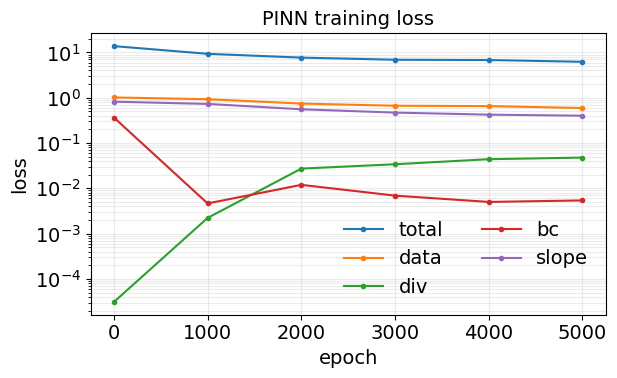

In [11]:
# PINN training-loss plot.
if not pinn_history.get("epoch"):
    print("No PINN loss history found. Run the PINN training cell first.")
else:
    epochs = np.asarray(pinn_history["epoch"], dtype=float)
    loss_keys = ["loss", "data", "div", "bc_flux", "slope"]
    loss_labels = {
        "loss": "total",
        "data": "data",
        "div": "div",
        "bc_flux": "bc",
        "slope": "slope",
    }
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, ax = plt.subplots(figsize=(6.4, 4.0))
        for key in loss_keys:
            vals = np.asarray(pinn_history.get(key, []), dtype=float)
            if vals.size == epochs.size and vals.size > 0:
                ax.semilogy(epochs, np.maximum(vals, 1.0e-30), marker="o", ms=3, lw=1.5, label=loss_labels[key])
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.set_title("PINN training loss")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False, ncol=2)
        fig.tight_layout()
        plt.show()


PINN gradient-component absolute error at triangle centroids:
  |dpx_theta-dpx_h| mean=1.322e+00, max=1.808e+01
  |dpy_theta-dpy_h| mean=9.863e-01, max=1.387e+01


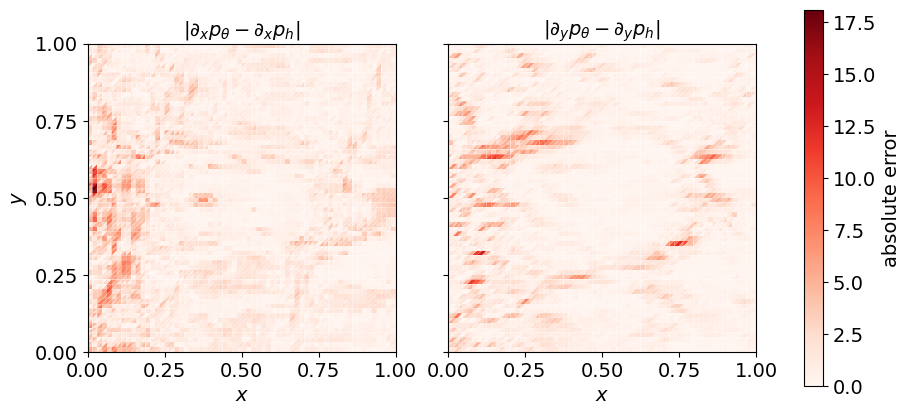

In [14]:
# PINN gradient-component absolute error at the CG triangle centroids.
grad_theta_tri = grad_rec_numpy(_data_pts_np)
grad_cg_tri = np.asarray(_data_grad_cg_np, dtype=float)
abs_grad_err_tri = np.abs(grad_theta_tri - grad_cg_tri)
abs_grad_err_x = abs_grad_err_tri[:, 0]
abs_grad_err_y = abs_grad_err_tri[:, 1]

print(
    "PINN gradient-component absolute error at triangle centroids:\n"
    f"  |dpx_theta-dpx_h| mean={np.mean(abs_grad_err_x):.3e}, max={np.max(abs_grad_err_x):.3e}\n"
    f"  |dpy_theta-dpy_h| mean={np.mean(abs_grad_err_y):.3e}, max={np.max(abs_grad_err_y):.3e}"
)

tri_polys_for_grad_err_plot = fem_nodes[triangles]
err_vmax = float(np.nanmax(abs_grad_err_tri))
if not np.isfinite(err_vmax) or err_vmax <= 0.0:
    err_vmax = 1.0

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), constrained_layout=True)
    for ax, vals, title in [
        (axes[0], abs_grad_err_x, r"$|\partial_x p_\theta-\partial_x p_h|$"),
        (axes[1], abs_grad_err_y, r"$|\partial_y p_\theta-\partial_y p_h|$"),
    ]:
        pc = PolyCollection(
            tri_polys_for_grad_err_plot,
            edgecolors="none",
            linewidths=0.0,
            cmap="Reds",
            rasterized=True,
        )
        pc.set_array(np.asarray(vals, dtype=float))
        pc.set_clim(0.0, err_vmax)
        ax.add_collection(pc)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_xlabel(r"$x$")
        ax.set_title(title)
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    axes[1].tick_params(labelleft=False)
    cbar = fig.colorbar(pc, ax=axes, fraction=0.046, pad=0.04)
    cbar.set_label(r"absolute error")
    plt.show()


In [12]:
# MRST face orientation -> owner/neighbour records.
n1 = face_neighbors[:, 0].astype(int)
n2 = face_neighbors[:, 1].astype(int)
is_internal_face = (n1 > 0) & (n2 > 0)
is_boundary_face = ~is_internal_face

owner_int = n1[is_internal_face] - 1
neigh_int = n2[is_internal_face] - 1
owner_b = np.maximum(n1[is_boundary_face], n2[is_boundary_face]) - 1
sgn_b = np.ones(np.count_nonzero(is_boundary_face), dtype=float)
sgn_b[n1[is_boundary_face] == 0] = -1.0

owner = np.concatenate([owner_int, owner_b]).astype(int)
neigh = np.concatenate([neigh_int, -np.ones_like(owner_b)]).astype(int)
has_neighbor = neigh >= 0
is_boundary_conn = ~has_neighbor

INFLOW_BC_S = 1.0
boundary_face_centers = face_centroid[is_boundary_face]
inlet_boundary_b = np.isclose(boundary_face_centers[:, 0], physdim[0], atol=1.0e-10)
inlet_s_b = np.zeros_like(owner_b, dtype=float)
inlet_s_b[inlet_boundary_b] = INFLOW_BC_S
inlet_s = np.concatenate([np.zeros_like(owner_int, dtype=float), inlet_s_b])


def global_face_flux_to_fout(global_face_flux):
    global_face_flux = np.asarray(global_face_flux, dtype=float).reshape(-1)
    return np.concatenate([
        global_face_flux[is_internal_face],
        global_face_flux[is_boundary_face] * sgn_b,
    ]).astype(float)


def _face_quadrature(n_quad=2):
    if n_quad == 1:
        return np.array([0.5], dtype=float), np.array([1.0], dtype=float)
    xi, wi = np.polynomial.legendre.leggauss(n_quad)
    return 0.5 * (xi + 1.0), 0.5 * wi


def face_global_flux_from_velocity(velocity_fn, n_quad=2):
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = velocity_fn(pts)
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux


def face_global_flux_from_cg_average(n_quad=2):
    """Two-sided averaged CG trace on internal rectangular faces.

    Boundary faces use the one-sided interior trace.  Internal faces use
    0.5*(v_h|_{C1}+v_h|_{C2}) before taking the normal component, removing the
    arbitrary side selection from the raw CG baseline.
    """
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = np.zeros_like(pts)
        if np.any(internal):
            q1 = q_cg_on_rect_cell_numpy(pts[internal], cell1[internal])
            q2 = q_cg_on_rect_cell_numpy(pts[internal], cell2[internal])
            vel[internal] = 0.5 * (q1 + q2)
        if np.any(~internal):
            vel[~internal] = q_cg_on_rect_cell_numpy(pts[~internal], owner_cell[~internal])
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux


def face_global_flux_from_deng_average(n_quad=2):
    """Two-sided averaged Deng/NLR trace on internal rectangular faces."""
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = np.zeros_like(pts)
        if np.any(internal):
            q1 = q_deng_on_rect_cell_numpy(pts[internal], cell1[internal])
            q2 = q_deng_on_rect_cell_numpy(pts[internal], cell2[internal])
            vel[internal] = 0.5 * (q1 + q2)
        if np.any(~internal):
            vel[~internal] = q_deng_on_rect_cell_numpy(pts[~internal], owner_cell[~internal])
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux

def face_global_flux_from_gradient_harmonic(gradient_fn, n_quad=2):
    """Integrate -kappa_face * g_theta.n on MRST/transport faces.

    Internal faces use the harmonic mean of the two adjacent DG0 permeabilities;
    boundary faces use the owner-cell permeability.
    """
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    k_face = np.empty(face_len.size, dtype=float)
    k_face[internal] = harmonic_mean(kappa_cell_dg0[cell1[internal]], kappa_cell_dg0[cell2[internal]])
    k_face[~internal] = kappa_cell_dg0[owner_cell[~internal]]
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        grad = gradient_fn(pts)
        vel = -k_face[:, None] * grad
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux


if CG_INTERFACE_FLUX_MODE == "average":
    face_flux_cg_global = face_global_flux_from_cg_average(n_quad=2)
    print("CG face flux convention: two-sided averaged CG trace on internal rectangular faces; one-sided interior trace on boundaries.")
elif CG_INTERFACE_FLUX_MODE == "geometric":
    face_flux_cg_global = face_global_flux_from_velocity(q_cg_numpy, n_quad=1)
    print("CG face flux convention: previous one-sided geometric locate_structured_triangles() trace.")
else:
    raise ValueError("CG_INTERFACE_FLUX_MODE must be 'average' or 'geometric'.")
face_flux_nlr_global = face_global_flux_from_deng_average(n_quad=2)
face_flux_rec_global = face_global_flux_from_gradient_harmonic(grad_rec_numpy, n_quad=2)
print("NLR face flux convention: two-sided averaged Deng/NLR trace on internal rectangular faces; one-sided interior trace on boundaries.")
print("PINN face flux convention: gradient network with harmonic face permeability.")
Fout_CG = global_face_flux_to_fout(face_flux_cg_global)
Fout_NLR = global_face_flux_to_fout(face_flux_nlr_global)
Fout_PINN = global_face_flux_to_fout(face_flux_rec_global)
Fout_MRST = global_face_flux_to_fout(face_flux_mrst)

transport_fluxes = {"CG": Fout_CG, "NLR": Fout_NLR, "PINN": Fout_PINN, "MRST": Fout_MRST}
face_flux_by_method = {"CG": face_flux_cg_global, "NLR": face_flux_nlr_global, "PINN": face_flux_rec_global, "MRST": face_flux_mrst}


def cell_single_phase_residual(Fout):
    residual = np.zeros(ncell, dtype=float)
    np.add.at(residual, owner, Fout)
    np.add.at(residual, neigh[has_neighbor], -Fout[has_neighbor])
    return residual - source_rate_cell

print("Face-flux comparison relative to MRST/TPFA:")
for name, Fout in transport_fluxes.items():
    err = Fout - Fout_MRST
    print(f"  {name:<4} mean|F-F_FV|={np.mean(np.abs(err)):.3e}, rmse={np.sqrt(np.mean(err**2)):.3e}, max|F-F_FV|={np.max(np.abs(err)):.3e}")

print("Single-phase cell balance, sum outward face flux minus cell source int_K f:")
for name, Fout in transport_fluxes.items():
    r = cell_single_phase_residual(Fout)
    print(f"  {name:<4} {residual_stats(r)}")

print("Boundary single-phase flux audit (signed outward sums):")
_boundary_masks = {
    "left": is_boundary_face & np.isclose(face_centroid[:, 0], xmin, atol=1.0e-12),
    "right": is_boundary_face & np.isclose(face_centroid[:, 0], xmax, atol=1.0e-12),
    "bottom": is_boundary_face & np.isclose(face_centroid[:, 1], ymin, atol=1.0e-12),
    "top": is_boundary_face & np.isclose(face_centroid[:, 1], ymax, atol=1.0e-12),
}
for side, full_mask in _boundary_masks.items():
    row = [f"  {side:<6}"]
    for name, flux in face_flux_by_method.items():
        row.append(f"{name} sum={np.sum(flux[full_mask]):+.3e}, sum|F|={np.sum(np.abs(flux[full_mask])):.3e}")
    print("; ".join(row))

print("Boundary transport-convention audit (outward from matrix cells):")
_boundary_face_ids = np.flatnonzero(is_boundary_face)
for side, full_mask in _boundary_masks.items():
    side_b = full_mask[_boundary_face_ids]
    row = [f"  {side:<6}"]
    for name, Fout in transport_fluxes.items():
        Fb = Fout[owner_int.size:][side_b]
        row.append(
            f"{name}: out={np.sum(np.maximum(Fb, 0.0)):.3e}, "
            f"in={np.sum(np.maximum(-Fb, 0.0)):.3e}"
        )
    print("; ".join(row))


CG face flux convention: two-sided averaged CG trace on internal rectangular faces; one-sided interior trace on boundaries.
PINN face flux convention: gradient network with harmonic face permeability.
Face-flux comparison relative to MRST/TPFA:
  CG   mean|F-F_FV|=9.517e-03, rmse=2.265e-02, max|F-F_FV|=2.912e-01
  PINN mean|F-F_FV|=3.206e-02, rmse=7.863e-02, max|F-F_FV|=1.647e+00
  MRST mean|F-F_FV|=0.000e+00, rmse=0.000e+00, max|F-F_FV|=0.000e+00
Single-phase cell balance, sum outward face flux minus cell source int_K f:
  CG   n=4096 mean|R|=2.026156e-02 median|R|=6.773625e-03 rmse=4.675293e-02 max|R|=5.578350e-01 sum(R)=-1.345908e-02
  PINN n=4096 mean|R|=2.811825e-02 median|R|=9.439519e-03 rmse=7.825282e-02 max|R|=2.243286e+00 sum(R)=-5.015320e+00
  MRST n=4096 mean|R|=7.993304e-15 median|R|=1.072059e-15 rmse=2.910507e-14 max|R|=6.551981e-13 sum(R)=+1.463803e-12
Boundary single-phase flux audit (signed outward sums):
  left   CG sum=-5.681e+00, sum|F|=5.681e+00; PINN sum=-2.641e+00

In [ ]:
# Rotated rectangular transport-CV residual R_zeta.
ROT_RECT_ANGLE_DEG = 45.0
ROT_RECT_HU = 1.0 * h_est
ROT_RECT_HV = 1.0 * h_est
ROT_RECT_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
ROT_RECT_SHIFT_U = float(ROT_RECT_SHIFT_FRACTION[0] * ROT_RECT_HU)
ROT_RECT_SHIFT_V = float(ROT_RECT_SHIFT_FRACTION[1] * ROT_RECT_HV)
ROT_RECT_EDGE_NQ = 4
ROT_RECT_MIN_AREA = 1.0e-14
ROT_RECT_CMAP = "RdBu_r"
ROT_RECT_OUTLINE_COLOR = "0.25"
ROT_RECT_OUTLINE_WIDTH = 0.15
ROT_RECT_LOG_CLIM = (-8.0, -2.0)
ROT_RECT_COLORBAR_MODE = "shared"  # "shared" or "independent"


def clip_polygon_axis_bound(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = [np.asarray(p, dtype=float) for p in poly]
    if not poly:
        return []

    def inside(p):
        return p[axis] <= bound + tol if keep_less else p[axis] >= bound - tol

    out = []
    prev = poly[-1]
    prev_in = inside(prev)
    for cur in poly:
        cur_in = inside(cur)
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > 1.0e-15:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return out


def clip_polygon_to_bbox(poly):
    out = [np.asarray(p, dtype=float) for p in poly]
    for axis, bound, keep_less in [(0, xmin, False), (0, xmax, True), (1, ymin, False), (1, ymax, True)]:
        out = clip_polygon_axis_bound(out, axis, bound, keep_less)
        if len(out) == 0:
            return np.zeros((0, 2), dtype=float)
    return order_polygon_vertices(np.asarray(out, dtype=float))


def rotated_rect_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    H = float(H)
    if H <= 0.0:
        raise ValueError("The rotated-rectangle CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [float(lo), float(hi)]
    x = float(lo) + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_rotated_rectangles():
    theta = np.deg2rad(ROT_RECT_ANGLE_DEG)
    e_u = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    e_v = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox_poly = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    bbox_uv = np.column_stack(((bbox_poly - origin) @ e_u, (bbox_poly - origin) @ e_v))
    u_lines = rotated_rect_grid_lines(bbox_uv[:, 0].min(), bbox_uv[:, 0].max(), ROT_RECT_HU, ROT_RECT_SHIFT_U)
    v_lines = rotated_rect_grid_lines(bbox_uv[:, 1].min(), bbox_uv[:, 1].max(), ROT_RECT_HV, ROT_RECT_SHIFT_V)
    polys, centers, areas = [], [], []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            rect_xy = origin + corners_uv[:, 0:1] * e_u[None, :] + corners_uv[:, 1:2] * e_v[None, :]
            poly = clip_polygon_to_bbox(rect_xy)
            if len(poly) < 3:
                continue
            area = abs(polygon_signed_area(poly))
            if area <= ROT_RECT_MIN_AREA:
                continue
            polys.append(poly)
            centers.append(poly.mean(axis=0))
            areas.append(float(area))
    return polys, np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def integrate_velocity_on_polygon(poly, velocity_fn):
    edge_q, edge_w = np.polynomial.legendre.leggauss(ROT_RECT_EDGE_NQ)
    edge_q = 0.5 * (edge_q + 1.0)
    edge_w = 0.5 * edge_w
    poly = order_polygon_vertices(poly)
    centroid = poly.mean(axis=0)
    total = 0.0
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        seg = x1 - x0
        seg_len = edge_length(x0, x1)
        if seg_len <= 1.0e-15:
            continue
        n_len = outward_edge_normal(x0, x1, centroid) * seg_len
        xq = x0[None, :] + edge_q[:, None] * seg[None, :]
        q = velocity_fn(xq)
        total += float(np.sum(edge_w * (q @ n_len)))
    return total


def integrate_source_on_polygon(poly):
    poly = order_polygon_vertices(poly)
    ctr = poly.mean(axis=0)
    total = 0.0
    for j in range(len(poly)):
        tri = np.vstack([ctr, poly[j], poly[(j + 1) % len(poly)]])
        area = abs(polygon_signed_area(tri))
        if area <= 1.0e-15:
            continue
        xq = _TRI_BARY @ tri
        total += area * float(np.sum(_TRI_W * f_numpy(xq)))
    return total

rotated_rect_polys, rotated_rect_centers, rotated_rect_areas = build_rotated_rectangles()
rotated_rect_source = np.asarray([integrate_source_on_polygon(poly) for poly in rotated_rect_polys], dtype=float)
R_rotated_rect_cg = np.asarray([integrate_velocity_on_polygon(poly, q_cg_numpy) for poly in rotated_rect_polys], dtype=float) - rotated_rect_source
R_rotated_rect_nlr = np.asarray([integrate_velocity_on_polygon(poly, q_deng_numpy) for poly in rotated_rect_polys], dtype=float) - rotated_rect_source
R_rotated_rect_rec = np.asarray([integrate_velocity_on_polygon(poly, q_rec_numpy) for poly in rotated_rect_polys], dtype=float) - rotated_rect_source

print("Rotated rectangular transport-CV residual R_zeta")
print(f"  rectangles: {len(rotated_rect_polys)}")
print(f"  angle={ROT_RECT_ANGLE_DEG:.6g} deg, Hu={ROT_RECT_HU:.6g}, Hv={ROT_RECT_HV:.6g}, shift=({ROT_RECT_SHIFT_U:.6g}, {ROT_RECT_SHIFT_V:.6g})")
print(f"  source integral over zeta CVs: sum={np.sum(rotated_rect_source):+.6e}")
print("  CG  :", residual_stats(R_rotated_rect_cg))
print("  NLR :", residual_stats(R_rotated_rect_nlr))
print("  PINN:", residual_stats(R_rotated_rect_rec))
for name, vals in [("CG", R_rotated_rect_cg), ("NLR", R_rotated_rect_nlr), ("PINN", R_rotated_rect_rec)]:
    vals = vals[np.isfinite(vals)]
    print(f"  {name:<4} sum(R_zeta^2)={np.sum(vals**2):.6e}, RMSE={np.sqrt(np.mean(vals**2)):.6e}")

_abs_R_cg = np.abs(R_rotated_rect_cg)
_abs_R_nlr = np.abs(R_rotated_rect_nlr)
_abs_R_rec = np.abs(R_rotated_rect_rec)
log_R_cg = np.log10(_abs_R_cg + 1.0e-30)
log_R_nlr = np.log10(_abs_R_nlr + 1.0e-30)
log_R_rec = np.log10(_abs_R_rec + 1.0e-30)


def _format_abs_tick(log_value):
    value = 10.0 ** float(log_value)
    if value == 0.0:
        return "0"
    exponent = int(np.floor(np.log10(abs(value))))
    coeff = value / (10.0 ** exponent)
    if np.isclose(coeff, 1.0):
        return rf"$10^{{{exponent}}}$"
    return rf"${coeff:.1f}\!\times\!10^{{{exponent}}}$"

_panels = [(log_R_cg, r"$R_\zeta(\mathbf{v}_h)$"), (log_R_nlr, r"$R_\zeta(\widetilde{\mathbf{v}}_h)$"), (log_R_rec, r"$R_\zeta(\mathbf{v}_\theta)$")]
if ROT_RECT_COLORBAR_MODE == "shared":
    if ROT_RECT_LOG_CLIM is None:
        finite = np.concatenate([log_R_cg[np.isfinite(log_R_cg)], log_R_nlr[np.isfinite(log_R_nlr)], log_R_rec[np.isfinite(log_R_rec)]])
        vmin, vmax = float(np.min(finite)), float(np.max(finite))
    else:
        vmin, vmax = map(float, ROT_RECT_LOG_CLIM)
    fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.1), constrained_layout=False)
    fig.subplots_adjust(left=0.05, right=0.90, bottom=0.12, top=0.86, wspace=0.18)
    pc = None
    for ax, (vals, title) in zip(axes, _panels):
        pc = PolyCollection(rotated_rect_polys, edgecolors=ROT_RECT_OUTLINE_COLOR, linewidths=ROT_RECT_OUTLINE_WIDTH, cmap=ROT_RECT_CMAP)
        pc.set_array(vals)
        pc.set_clim(vmin, vmax)
        ax.add_collection(pc)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)
        ax.tick_params(labelsize=14)
        ax.grid(False)
    fig.canvas.draw()
    axpos = axes[-1].get_position()
    cax = fig.add_axes([axpos.x1 + 0.015, axpos.y0, 0.018, axpos.height])
    cbar = fig.colorbar(pc, cax=cax)
    ticks = np.arange(-8.0, -1.0, 1.0)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"$10^{{{int(t)}}}$" for t in ticks])
    cbar.set_label(r"$|R_\zeta|$", fontsize=14)
    cbar.ax.tick_params(labelsize=14)
else:
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.1), constrained_layout=True)
    for ax, (vals, title) in zip(axes, _panels):
        finite = vals[np.isfinite(vals)]
        vmin, vmax = float(np.min(finite)), float(np.max(finite))
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
            vmin, vmax = -16.0, -1.0
        pc = PolyCollection(rotated_rect_polys, edgecolors=ROT_RECT_OUTLINE_COLOR, linewidths=ROT_RECT_OUTLINE_WIDTH, cmap=ROT_RECT_CMAP)
        pc.set_array(vals)
        pc.set_clim(vmin, vmax)
        ax.add_collection(pc)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)
        ax.tick_params(labelsize=14)
        ax.grid(False)
        cbar = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.02)
        ticks = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels([_format_abs_tick(t) for t in ticks])
        cbar.ax.tick_params(labelsize=14)
plt.show()


MRST/TPFA validation:
  matrix pressure          L2=5.644e-01 relL2=2.902e-03 mean|e|=6.013e-03 median|e|=4.069e-03 rmse=8.818e-03 max|e|=7.529e-02
  CG face flux             L2=2.066e+00 relL2=1.853e-01 mean|e|=9.517e-03 median|e|=2.999e-03 rmse=2.265e-02 max|e|=2.912e-01
  PINN face flux           L2=7.172e+00 relL2=6.432e-01 mean|e|=3.206e-02 median|e|=9.680e-03 rmse=7.863e-02 max|e|=1.647e+00


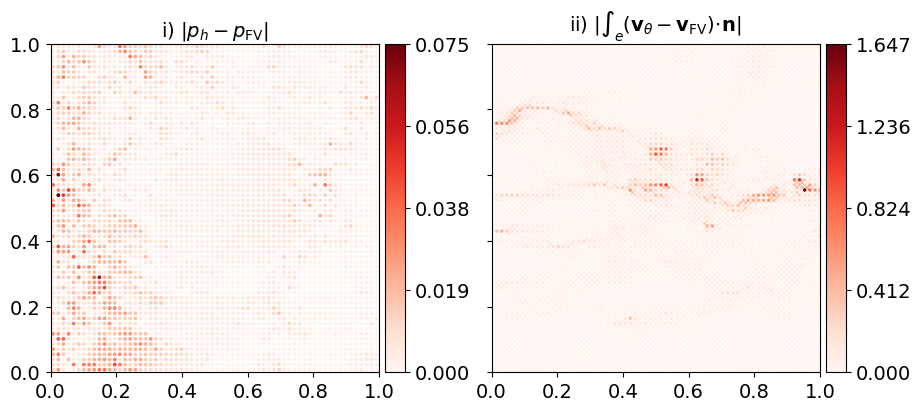

In [21]:
# MRST/TPFA validation maps.
def print_validation_stats(label, diff, ref=None):
    vals = np.asarray(diff, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        print(f"  {label:<24} no finite values")
        return
    l2 = float(np.sqrt(np.sum(vals ** 2)))
    rel = np.nan
    if ref is not None:
        r = np.asarray(ref, dtype=float).reshape(-1)
        denom = float(np.sqrt(np.sum(r ** 2)))
        if denom > 0.0:
            rel = float(l2 / denom)
    print(
        f"  {label:<24} L2={l2:.3e} relL2={rel:.3e} "
        f"mean|e|={np.mean(np.abs(vals)):.3e} "
        f"median|e|={np.median(np.abs(vals)):.3e} rmse={np.sqrt(np.mean(vals**2)):.3e} "
        f"max|e|={np.max(np.abs(vals)):.3e}"
    )

print("MRST/TPFA validation:")
print_validation_stats("matrix pressure", p_matrix_diff_cg_mrst, p_matrix_mrst)
print_validation_stats("CG face flux", face_flux_cg_global - face_flux_mrst, face_flux_mrst)
print_validation_stats("NLR face flux", face_flux_nlr_global - face_flux_mrst, face_flux_mrst)
print_validation_stats("PINN face flux", face_flux_rec_global - face_flux_mrst, face_flux_mrst)


from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

VALIDATION_USE_LOG_COLOR_SCALE = False
VALIDATION_SYMLOG_FLOOR = 1.0e-16
VALIDATION_SYMLOG_MIN_DECADES = 4.0


def _fixed_cbar_tick_label(value, decimals=3):
    value = float(value)
    if not np.isfinite(value):
        return ""
    text = f"{value:.{decimals}f}"
    return "0.000" if text == "-0.000" else text


def _symmetric_absmax(values, floor=1.0e-15):
    vals = np.asarray(values, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return float(floor)
    lim = float(np.max(np.abs(vals)))
    if not np.isfinite(lim) or lim <= 0.0:
        lim = float(floor)
    return lim


def _positive_abs_min(values, floor=1.0e-16):
    vals = np.asarray(values, dtype=float).reshape(-1)
    vals = np.abs(vals[np.isfinite(vals)])
    vals = vals[vals > 0.0]
    if vals.size == 0:
        return float(floor)
    return max(float(np.min(vals)), float(floor))


def _log_abs_norm_ticks(values):
    vals = np.abs(np.asarray(values, dtype=float).reshape(-1))
    vals = vals[np.isfinite(vals)]
    vals_pos = vals[vals > 0.0]
    if vals_pos.size == 0:
        vmin, vmax = VALIDATION_SYMLOG_FLOOR, 10.0 * VALIDATION_SYMLOG_FLOOR
    else:
        vmin = max(float(np.min(vals_pos)), float(VALIDATION_SYMLOG_FLOOR))
        vmax = max(float(np.max(vals_pos)), 10.0 * vmin)
    ticks = np.geomspace(vmin, vmax, 5)
    return LogNorm(vmin=vmin, vmax=vmax), ticks


def _scatter_abs_error_map(ax, x, y, values, size):
    vals = np.abs(np.asarray(values, dtype=float))
    if VALIDATION_USE_LOG_COLOR_SCALE:
        norm, ticks = _log_abs_norm_ticks(vals)
        sc = ax.scatter(x, y, c=np.maximum(vals, norm.vmin), s=size, cmap="Reds", norm=norm, rasterized=True)
    else:
        lim = _symmetric_absmax(vals)
        ticks = np.linspace(0.0, lim, 5)
        sc = ax.scatter(x, y, c=vals, s=size, cmap="Reds", vmin=0.0, vmax=lim, rasterized=True)
    return sc, ticks


with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    sc_p, p_ticks = _scatter_abs_error_map(
        axes[0], xc_matrix[:, 0], xc_matrix[:, 1], p_matrix_diff_cg_mrst, 3,
    )
    axes[0].set_xlim(xmin, xmax)
    axes[0].set_ylim(ymin, ymax)
    axes[0].set_aspect("equal")
    axes[0].set_title(r"i) $|p_h-p_{\mathrm{FV}}|$")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    axes[0].grid(False)
    div_p = make_axes_locatable(axes[0])
    cax_p = div_p.append_axes("right", size="6%", pad=0.06)
    cbar_p = fig.colorbar(sc_p, cax=cax_p)
    cbar_p.set_ticks(p_ticks)
    cbar_p.set_ticklabels([_fixed_cbar_tick_label(t) for t in p_ticks])

    fdiff = face_flux_rec_global - face_flux_mrst
    sc_f, f_ticks = _scatter_abs_error_map(
        axes[1], face_centroid[:, 0], face_centroid[:, 1], fdiff, 2.5,
    )
    axes[1].set_xlim(xmin, xmax)
    axes[1].set_ylim(ymin, ymax)
    axes[1].set_aspect("equal")
    axes[1].set_title(r"ii) $|\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\!\cdot\!\mathbf{n}|$")
    axes[1].set_xlabel("")
    axes[1].tick_params(labelleft=False)
    axes[1].grid(False)
    div_f = make_axes_locatable(axes[1])
    cax_f = div_f.append_axes("right", size="6%", pad=0.06)
    cbar_f = fig.colorbar(sc_f, cax=cax_f)
    cbar_f.set_ticks(f_ticks)
    cbar_f.set_ticklabels([_fixed_cbar_tick_label(t) for t in f_ticks])
    plt.show()


PINN face-flux absolute error quantiles |\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\cdot\mathbf{n}\,ds|:
  min=0.000000, q25=0.002363, median=0.009680, q75=0.030962, q90=0.076247, q99=0.348091, max=1.647452


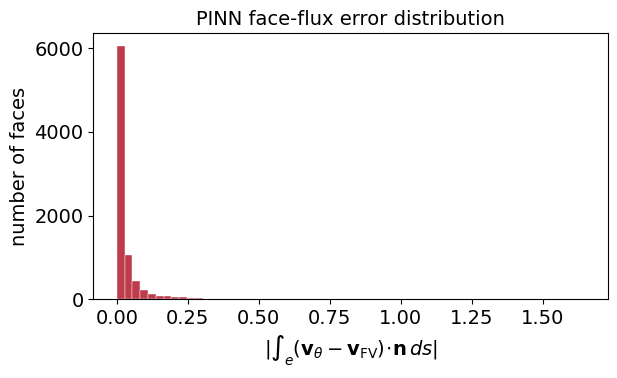

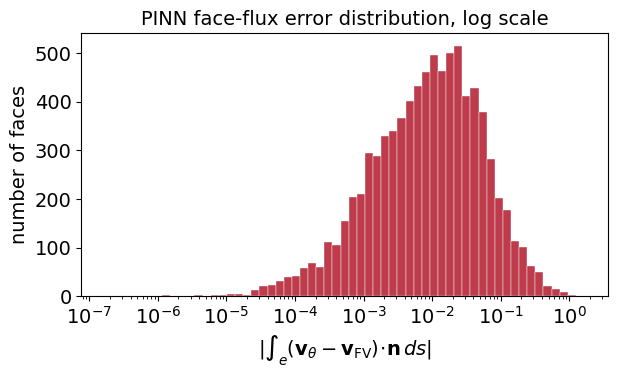

In [17]:
# Histogram of the PINN--MRST integrated face-flux error.
pinn_face_flux_abs_err = np.abs(face_flux_rec_global - face_flux_mrst)
pinn_face_flux_abs_err = pinn_face_flux_abs_err[np.isfinite(pinn_face_flux_abs_err)]
if pinn_face_flux_abs_err.size == 0:
    print("No finite PINN face-flux errors to plot.")
else:
    q = np.quantile(pinn_face_flux_abs_err, [0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0])
    print(
        "PINN face-flux absolute error quantiles "
        r"|\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\cdot\mathbf{n}\,ds|:" "\n"
        f"  min={q[0]:.6f}, q25={q[1]:.6f}, median={q[2]:.6f}, q75={q[3]:.6f}, "
        f"q90={q[4]:.6f}, q99={q[5]:.6f}, max={q[6]:.6f}"
    )
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, ax = plt.subplots(figsize=(6.4, 4.0))
        ax.hist(pinn_face_flux_abs_err, bins=60, color="#b2182b", alpha=0.85, edgecolor="white", linewidth=0.35)
        ax.set_xlabel(r"$|\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\!\cdot\!\mathbf{n}\,ds|$")
        ax.set_ylabel("number of faces")
        ax.set_title("PINN face-flux error distribution")
        ax.grid(False)
        fig.tight_layout()
        plt.show()

        positive_err = pinn_face_flux_abs_err[pinn_face_flux_abs_err > 0.0]
        n_zero = pinn_face_flux_abs_err.size - positive_err.size
        if positive_err.size == 0:
            print("No positive PINN face-flux errors for the log-scale histogram.")
        else:
            if n_zero > 0:
                print(f"Log-scale histogram omits {n_zero} exactly zero face errors.")
            vmin = float(np.min(positive_err))
            vmax = float(np.max(positive_err))
            if np.isclose(vmin, vmax):
                vmin = max(vmin / 10.0, np.finfo(float).tiny)
                vmax = vmax * 10.0
            log_bins = np.geomspace(vmin, vmax, 60)
            fig, ax = plt.subplots(figsize=(6.4, 4.0))
            ax.hist(positive_err, bins=log_bins, color="#b2182b", alpha=0.85, edgecolor="white", linewidth=0.35)
            ax.set_xscale("log")
            ax.set_xlabel(r"$|\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\!\cdot\!\mathbf{n}\,ds|$")
            ax.set_ylabel("number of faces")
            ax.set_title("PINN face-flux error distribution, log scale")
            ax.grid(False)
            fig.tight_layout()
            plt.show()


In [18]:
# Explicit upwind Buckley-Leverett transport on the matrix cells.
def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def compute_transport_dt(Fout):
    outflow = np.zeros(ncell, dtype=float)
    np.add.at(outflow, owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, neigh[has_neighbor], np.maximum(-Fout[has_neighbor], 0.0))
    outflow += np.abs(source_rate_cell)
    active = outflow > 1.0e-30
    if not np.any(active):
        raise RuntimeError("No outflow faces found for the fixed flux field.")
    return CFL * np.min(cell_pv[active] / (FPRIME_MAX * outflow[active]))


def advance_transport(Fout, t_final, clip=True, nsteps_override=None):
    Fout = np.asarray(Fout, dtype=float)
    dt_cfl = compute_transport_dt(Fout)
    if nsteps_override is None:
        nsteps = max(1, int(np.ceil(float(t_final) / dt_cfl)))
        dt_source = "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "shared MRST/TPFA CFL"
    dt = float(t_final) / nsteps
    dt_over_pv = dt / cell_pv

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & is_boundary_conn
    boundary_outflow = outward & is_boundary_conn
    up_cell = np.empty_like(owner)
    up_cell[outward] = owner[outward]
    interior_negative = (~outward) & has_neighbor
    up_cell[interior_negative] = neigh[interior_negative]
    up_cell[incoming_boundary] = owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(inlet_s) * Fout

    S = np.zeros(ncell, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    cumulative_source = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clipped_count = 0
    clip_mass_delta = 0.0

    for _ in range(nsteps):
        water_flux = fractional_flow_bl(S[up_cell]) * Fout
        water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
        wb = water_flux[is_boundary_conn]
        cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
        cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))

        div = np.zeros(ncell, dtype=float)
        np.add.at(div, owner, water_flux)
        np.add.at(div, neigh[has_neighbor], -water_flux[has_neighbor])
        source_water = fractional_flow_bl(S) * source_rate_cell
        cumulative_source += dt * float(np.sum(source_water))
        S_new = S - dt_over_pv * (div - source_water)
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * cell_pv))
            S = S_clip
        else:
            S = S_new

    mass = float(np.sum(S * cell_pv))
    net = float(cumulative_in - cumulative_out + cumulative_source)
    boundary_inflow_rate = float(np.sum(np.maximum(-Fout[owner_int.size:], 0.0)))
    return S, {
        "T": float(t_final),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "nsteps": int(nsteps),
        "dt_source": dt_source,
        "water_in": float(cumulative_in),
        "water_out": float(cumulative_out),
        "water_source": float(cumulative_source),
        "water_net": net,
        "water_mass": mass,
        "water_balance_error": float(mass - net),
        "water_balance_error_pct_in": float(100.0 * (mass - net) / cumulative_in) if cumulative_in > 0.0 else np.nan,
        "preclip_min": float(preclip_min),
        "preclip_max": float(preclip_max),
        "clip_mass_delta": float(clip_mass_delta),
        "clipped_count": int(clipped_count),
        "boundary_inflow": boundary_inflow_rate,
        "right_inflow": boundary_inflow_rate,
        "pvi": float(t_final * boundary_inflow_rate / PV_matrix),
    }


def rmse(a, b):
    d = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    return float(np.sqrt(np.mean(d * d)))


def maxabs(a, b):
    return float(np.max(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

TRANSPORT_CLIP = True
TRANSPORT_USE_SHARED_DT = True
reference_dt = compute_transport_dt(Fout_MRST)
reference_nsteps = {key: max(1, int(np.ceil(tfinal / reference_dt))) for key, _, _, tfinal, _ in transport_cases}

transport_results = {}
for key, sw_key, matched_key, tfinal, pvi in transport_cases:
    transport_results[key] = {}
    nsteps_ref = reference_nsteps[key] if TRANSPORT_USE_SHARED_DT else None
    for name, Fout in transport_fluxes.items():
        S, meta = advance_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=nsteps_ref)
        transport_results[key][name] = {"S": S, "meta": meta}

transport_rect_saturation = {name: transport_results[TRANSPORT_CASE_KEY][name]["S"] for name in transport_fluxes}
transport_rect_meta = {name: transport_results[TRANSPORT_CASE_KEY][name]["meta"] for name in transport_fluxes}
transport_rect_method_names = np.asarray(["CG", "NLR", "PINN", "MRST"], dtype=object)
transport_rect_S = np.vstack([transport_rect_saturation[name] for name in transport_rect_method_names])
transport_rect_water_mass = np.asarray([transport_rect_meta[name]["water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_net = np.asarray([transport_rect_meta[name]["water_net"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error = np.asarray([transport_rect_meta[name]["water_balance_error"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error_pct_in = np.asarray([transport_rect_meta[name]["water_balance_error_pct_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_dt = np.asarray([transport_rect_meta[name]["dt"] for name in transport_rect_method_names], dtype=float)
transport_rect_nsteps = np.asarray([transport_rect_meta[name]["nsteps"] for name in transport_rect_method_names], dtype=np.int32)

print(f"Transport clipping enabled: {TRANSPORT_CLIP}")
print("Shared transport timestep policy:")
for key, _, _, tfinal, pvi in transport_cases:
    print(f"  {key:<7} nsteps_ref={reference_nsteps[key]}, dt_ref={tfinal/reference_nsteps[key]:.8e}, PVI={pvi:.6f}")

print("Transport diagnostics relative to matched MRST/TPFA upwind transport:")
print("  case    method  nsteps        dt       PVI       RMSE      max|e|      clip dM    balance/in")
for key, sw_key, matched_key, _, _ in transport_cases:
    reference_key = matched_key if matched_key in mrst else sw_key
    native = _arr(reference_key, float).reshape(-1)
    for name in transport_rect_method_names:
        item = transport_results[key][name]
        S = item["S"]
        meta = item["meta"]
        print(
            f"  {key:<7} {name:<5} {meta['nsteps']:7d} {meta['dt']:10.4e} {meta['pvi']:8.4f} "
            f"{rmse(S, native):9.3e} {maxabs(S, native):9.3e} "
            f"{meta['clip_mass_delta']:11.3e} {meta['water_balance_error_pct_in']:11.3e}%"
        )

print("Transport saturation bounds:")
print("  case    method      min(S)      max(S)  preclip min  preclip max    clipped")
for key, _, _, _, _ in transport_cases:
    for name in transport_rect_method_names:
        item = transport_results[key][name]
        S = item["S"]
        meta = item["meta"]
        print(
            f"  {key:<7} {name:<5} {np.nanmin(S):11.4e} {np.nanmax(S):11.4e} "
            f"{meta['preclip_min']:11.4e} {meta['preclip_max']:11.4e} {meta['clipped_count']:10d}"
        )

print("MRST native explicitTransport saturation vs matched upwind reference:")
for key, sw_key, matched_key, _, _ in transport_cases:
    if matched_key in mrst:
        print(f"  {key:<7} RMSE={rmse(_arr(matched_key, float).reshape(-1), _arr(sw_key, float).reshape(-1)):.4e}")


Transport clipping enabled: True
Shared transport timestep policy:
  PVI0.3  nsteps_ref=2733, dt_ref=2.15889910e-05, PVI=0.300000
  PVI0.5  nsteps_ref=4555, dt_ref=2.15889910e-05, PVI=0.500000
Transport diagnostics relative to matched MRST/TPFA upwind transport:
  case    method  nsteps        dt       PVI       RMSE      max|e|    balance/in
  PVI0.3  CG       2733 2.1589e-05   0.3431 1.826e-01 6.421e-01  -4.120e+01%
  PVI0.3  PINN     2733 2.1589e-05   0.4521 3.141e-01 9.269e-01  -7.006e+01%
  PVI0.3  MRST     2733 2.1589e-05   0.3000 6.903e-17 6.661e-16   2.424e-12%
  PVI0.5  CG       4555 2.1589e-05   0.5718 2.231e-01 9.778e-01  -4.406e+01%
  PVI0.5  PINN     4555 2.1589e-05   0.7535 3.728e-01 8.931e-01  -7.529e+01%
  PVI0.5  MRST     4555 2.1589e-05   0.5000 9.050e-17 1.332e-15   2.554e-12%
Transport saturation bounds:
  case    method      min(S)      max(S)  preclip min  preclip max
  PVI0.3  CG     0.0000e+00  1.0000e+00  0.0000e+00  1.0430e+00
  PVI0.3  PINN   0.0000e+00  1.00

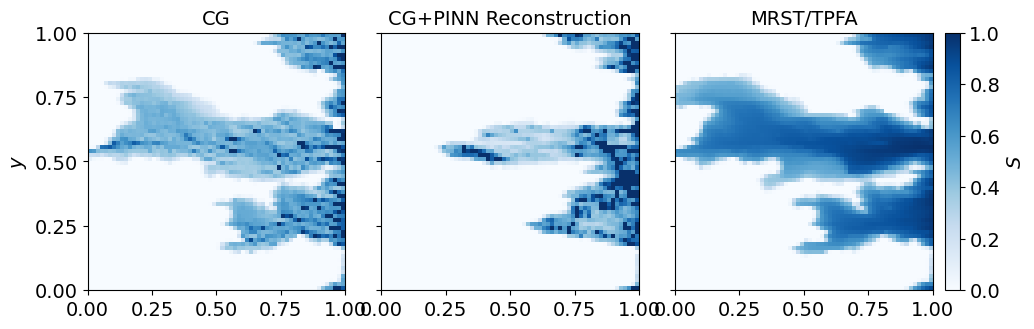

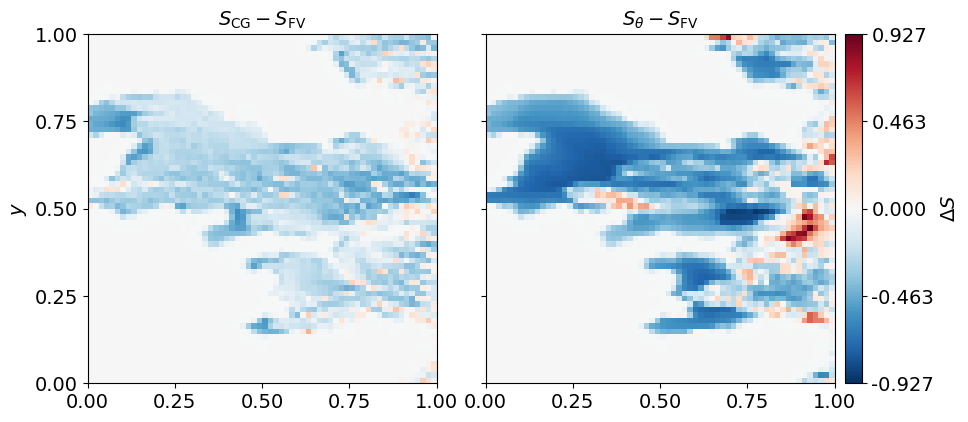

Selected case: PVI0.3, T=5.90027125e-02, PVI=0.300000
Saturation error relative to matched MRST/TPFA upwind transport:
  CG-MRST   mean|e|=1.100e-01 rmse=1.826e-01 max|e|=6.421e-01
  PINN-MRST mean|e|=1.889e-01 rmse=3.141e-01 max|e|=9.269e-01
Global water mass balance on the matrix-only rectangular grid (zero source):
  method        stored water      boundary net       source term        total net    balance error    error/in       nsteps       dt
  CG         1.927075e-01     3.292269e-01     0.000000e+00     3.292269e-01  -1.365193e-01 -4.120e+01%     2733 2.1589e-05
  PINN       1.334569e-01     4.460791e-01     0.000000e+00     4.460791e-01  -3.126223e-01 -7.006e+01%     2733 2.1589e-05
  MRST       2.940917e-01     2.940917e-01     0.000000e+00     2.940917e-01   7.271961e-15  2.424e-12%     2733 2.1589e-05


In [19]:
# Saturation plots and final water balance for the selected matrix-only case.
def cell_field_to_grid(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    ix = np.rint((xc_matrix[:, 0] - 0.5 * hx) / hx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * hy) / hy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

case_lookup = {key: (sw_key, matched_key, tfinal, pvi) for key, sw_key, matched_key, tfinal, pvi in transport_cases}
selected_sw_key, selected_matched_key, selected_T, selected_PVI = case_lookup[TRANSPORT_CASE_KEY]

x_edges = np.linspace(0.0, physdim[0], nx + 1)
y_edges = np.linspace(0.0, physdim[1], ny + 1)
plot_methods = ["CG", "NLR", "PINN", "MRST"]
plot_titles = {"CG": "CG", "NLR": "CG+NLR Reconstruction", "PINN": "CG+PINN Reconstruction", "MRST": "MRST/TPFA"}

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))
    pcm = None
    for ax, name in zip(axes, plot_methods):
        field = transport_results[TRANSPORT_CASE_KEY][name]["S"]
        pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(field), cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
        ax.set_aspect("equal")
        ax.set_xlim(0.0, physdim[0])
        ax.set_ylim(0.0, physdim[1])
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_title(plot_titles[name])
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.95, wspace=0.14)
    fig.canvas.draw()
    pos = axes[-1].get_position()
    cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$S$")
    plt.show()

selected_reference_key = selected_matched_key if selected_matched_key in mrst else selected_sw_key
native_selected = _arr(selected_reference_key, float).reshape(-1)
transport_rect_error_method_names = np.asarray(["CG-MRST", "NLR-MRST", "PINN-MRST"], dtype=object)
transport_rect_S_error = np.vstack([
    transport_results[TRANSPORT_CASE_KEY]["CG"]["S"] - native_selected,
    transport_results[TRANSPORT_CASE_KEY]["NLR"]["S"] - native_selected,
    transport_results[TRANSPORT_CASE_KEY]["PINN"]["S"] - native_selected,
])

SAT_ERROR_COLOR_MODE = "linear"  # "symlog" reveals small signed errors; "linear" uses raw values.
SAT_ERROR_LINTHRESH = 2.0e-3
SAT_ERROR_CMAP = "RdBu_r"

_sat_err_lim = float(np.nanmax(np.abs(transport_rect_S_error)))
if not np.isfinite(_sat_err_lim) or _sat_err_lim <= 0.0:
    _sat_err_lim = 1.0e-12
_sat_err_ticks = np.array([-_sat_err_lim, -SAT_ERROR_LINTHRESH, 0.0, SAT_ERROR_LINTHRESH, _sat_err_lim], dtype=float)
if SAT_ERROR_COLOR_MODE == "symlog":
    from matplotlib.colors import SymLogNorm
    _sat_err_linthresh = min(float(SAT_ERROR_LINTHRESH), max(_sat_err_lim / 10.0, 1.0e-12))
    _sat_err_norm = SymLogNorm(linthresh=_sat_err_linthresh, linscale=0.45, vmin=-_sat_err_lim, vmax=_sat_err_lim, base=10.0)
    _sat_err_ticks = np.array([-_sat_err_lim, -_sat_err_linthresh, 0.0, _sat_err_linthresh, _sat_err_lim], dtype=float)
elif SAT_ERROR_COLOR_MODE == "linear":
    _sat_err_norm = None
    _sat_err_ticks = np.linspace(-_sat_err_lim, _sat_err_lim, 5)
else:
    raise ValueError("SAT_ERROR_COLOR_MODE must be 'symlog' or 'linear'.")

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
    pcm = None
    for ax, err, title in zip(
        axes,
        transport_rect_S_error,
        [r"$S_{\mathrm{CG}}-S_{\mathrm{FV}}$", r"$S_{\mathrm{NLR}}-S_{\mathrm{FV}}$", r"$S_{\theta}-S_{\mathrm{FV}}$"],
    ):
        if _sat_err_norm is None:
            pcm = ax.pcolormesh(
                x_edges, y_edges, cell_field_to_grid(err), cmap=SAT_ERROR_CMAP,
                vmin=-_sat_err_lim, vmax=_sat_err_lim, shading="flat",
            )
        else:
            pcm = ax.pcolormesh(
                x_edges, y_edges, cell_field_to_grid(err), cmap=SAT_ERROR_CMAP,
                norm=_sat_err_norm, shading="flat",
            )
        ax.set_aspect("equal")
        ax.set_xlim(0.0, physdim[0])
        ax.set_ylim(0.0, physdim[1])
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_title(title)
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    fig.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.95, wspace=0.14)
    fig.canvas.draw()
    pos = axes[-1].get_position()
    cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.018, pos.height])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_ticks(_sat_err_ticks)
    cbar.set_ticklabels([f"{t:.3f}" for t in _sat_err_ticks])
    cbar.set_label(r"$\Delta S$")
    plt.show()

print(f"Selected case: {TRANSPORT_CASE_KEY}, T={selected_T:.8e}, PVI={selected_PVI:.6f}")
print("Saturation error relative to matched MRST/TPFA upwind transport:")
for name, err in zip(transport_rect_error_method_names, transport_rect_S_error):
    print(f"  {name:<9} mean|e|={np.mean(np.abs(err)):.3e} rmse={np.sqrt(np.mean(err**2)):.3e} max|e|={np.max(np.abs(err)):.3e}")

print("Global water mass balance on the matrix-only rectangular grid (zero source):")
print("  method        stored water      boundary net       source term        total net    balance error       clip dM    error/in       nsteps       dt")
for name in transport_rect_method_names:
    meta = transport_rect_meta[str(name)]
    boundary_net = meta['water_in'] - meta['water_out']
    print(
        f"  {str(name):<6} {meta['water_mass']:16.6e} {boundary_net:16.6e} "
        f"{meta['water_source']:16.6e} {meta['water_net']:16.6e} "
        f"{meta['water_balance_error']:14.6e} {meta['clip_mass_delta']:13.6e} "
        f"{meta['water_balance_error_pct_in']:10.3e}% "
        f"{meta['nsteps']:8d} {meta['dt']:10.4e}"
    )


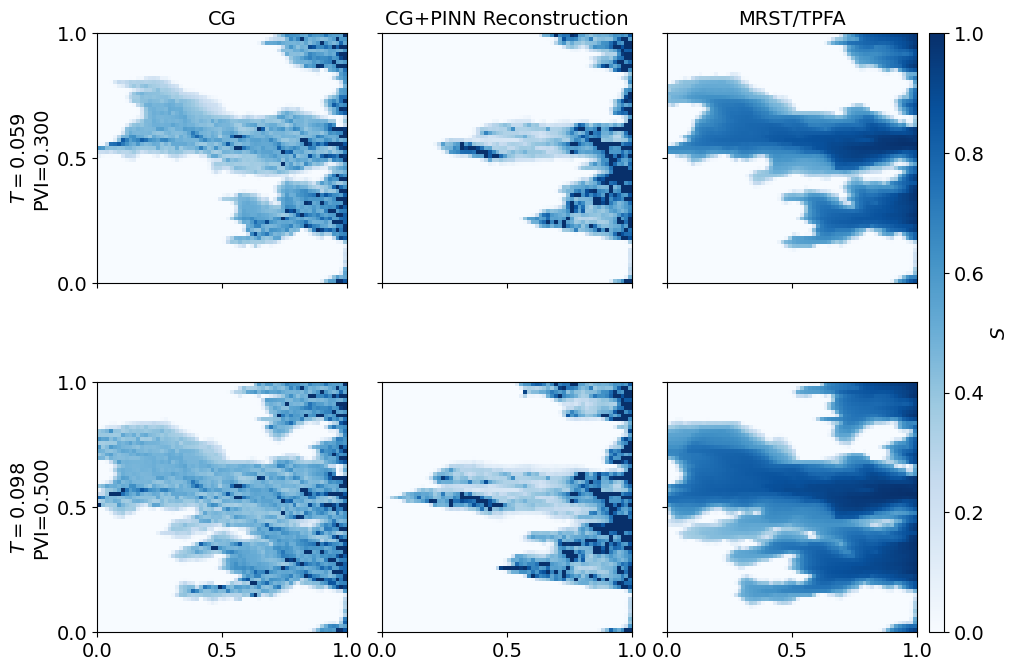

Time-step refinement check: shared SPE10 transport dt versus shared dt/2
  PVI0.3  CG    RMSE=1.1890e-04, max|e|=2.6220e-03, nsteps_half=5466
  PVI0.3  PINN  RMSE=1.1407e-04, max|e|=2.7617e-03, nsteps_half=5466
  PVI0.3  MRST  RMSE=9.8316e-05, max|e|=1.8219e-03, nsteps_half=5466
  PVI0.5  CG    RMSE=5.7913e-05, max|e|=1.4558e-03, nsteps_half=9110
  PVI0.5  PINN  RMSE=9.3578e-05, max|e|=2.5002e-03, nsteps_half=9110
  PVI0.5  MRST  RMSE=6.2456e-05, max|e|=9.0989e-04, nsteps_half=9110


In [20]:
# Plot the exported time snapshots without rerunning transport.
row_cases = transport_cases[:2]
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(len(row_cases), 3, figsize=(10, 3.8 * len(row_cases)), squeeze=False)
    pcm = None
    for ir, (key, sw_key, _, tfinal, pvi) in enumerate(row_cases):
        for ic, name in enumerate(plot_methods):
            ax = axes[ir, ic]
            field = transport_results[key][name]["S"]
            pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(field), cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.set_aspect("equal")
            ax.set_xlim(0.0, physdim[0])
            ax.set_ylim(0.0, physdim[1])
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.grid(False)
            if ir == 0:
                ax.set_title(plot_titles[name])
            if ic == 0:
                ax.set_ylabel(rf"$T={tfinal:.3f}$" + "\n" + rf"PVI={pvi:.3f}")
            else:
                ax.tick_params(labelleft=False)
            if ir < len(row_cases) - 1:
                ax.tick_params(labelbottom=False)
    fig.subplots_adjust(left=0.08, right=0.90, bottom=0.07, top=0.94, wspace=0.14, hspace=0.12)
    top = axes[0, -1].get_position()
    bottom = axes[-1, -1].get_position()
    cax = fig.add_axes([top.x1 + 0.012, bottom.y0, 0.015, top.y1 - bottom.y0])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$S$")
    plt.show()

print("Time-step refinement check: shared SPE10 transport dt versus shared dt/2")
for key, _, _, tfinal, _ in transport_cases:
    nsteps_ref = reference_nsteps[key]
    for name, Fout in transport_fluxes.items():
        S_dt = transport_results[key][name]["S"]
        S_half, meta_half = advance_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=2 * nsteps_ref)
        print(f"  {key:<7} {name:<5} RMSE={rmse(S_dt, S_half):.4e}, max|e|={maxabs(S_dt, S_half):.4e}, nsteps_half={meta_half['nsteps']}")


In [ ]:
# Save compact diagnostics for paper tables/figures.
outdir = pathlib.Path("result_koppel_martin_spe10_L20_no_fracture_pinn_matrix_only")
outdir.mkdir(exist_ok=True)
if TORCH_AVAILABLE and grad_net is not None:
    torch.save(
        {
            "grad_net": grad_net.state_dict(),
            "problem": "koppel_martin_spe10_L20_no_fracture",
            "reconstruction": "gradient_net_harmonic_face_kappa",
            "kappa": "SPE10 layer 20 DG0 kappa_cell",
            "SPE10_LAYER": float(SPE10_LAYER),
            "SPE10_CONTRAST": float(SPE10_CONTRAST),
            "source": "0",
            "gradient_data_samples": "triangle_centroids",
            "gradient_mean": _grad_mean_np.tolist(),
            "gradient_std": _grad_std_np.tolist(),
            "input_features": "x_y_log10kappa",
            "logk_mean": float(_logk_mean_np),
            "logk_std": float(_logk_std_np),
            "CG_INTERFACE_FLUX_MODE": CG_INTERFACE_FLUX_MODE,
            "xy_center": [0.5 * physdim[0], 0.5 * physdim[1]],
            "xy_scale": float(max(physdim)),
        },
        outdir / "matrix_only_pinn_gradient_reconstruction.pt",
    )
np.savez(
    outdir / "diagnostics.npz",
    xc_matrix=xc_matrix,
    p_matrix_cg=p_matrix_cg,
    p_matrix_mrst=p_matrix_mrst,
    p_matrix_diff_cg_mrst=p_matrix_diff_cg_mrst,
    kappa_cell_mrst=kappa_cell_mrst if kappa_cell_mrst is not None else kappa_numpy(xc_matrix),
    source_rate_cell=source_rate_cell,
    face_centroid=face_centroid,
    face_flux_mrst=face_flux_mrst,
    face_flux_cg=face_flux_cg_global,
    face_flux_nlr=face_flux_nlr_global,
    face_flux_pinn=face_flux_rec_global,
    q_nlr_elem=q_nlr_elem,
    grad_p_nlr_elem=grad_p_nlr_elem,
    R_tau_cg=R_tau_cg_avg,
    R_tau_nlr=R_tau_nlr_avg,
    R_xi_cg=R_xi_cg,
    R_xi_nlr=R_xi_nlr,
    R_xi_boundary_flux_cg=R_xi_boundary_flux_cg,
    R_xi_boundary_flux_nlr=R_xi_boundary_flux_nlr,
    xi_boundary_nodes=xi_boundary_nodes,
    xi_boundary_ids=xi_boundary_ids,
    xi_interior_ids=xi_interior_ids,
    reconstruction_type=np.asarray("gradient_net_harmonic_face_kappa"),
    gradient_data_samples=np.asarray("triangle_centroids"),
    gradient_mean=_grad_mean_np,
    gradient_std=_grad_std_np,
    input_features=np.asarray("x_y_log10kappa"),
    logk_mean=float(_logk_mean_np),
    logk_std=float(_logk_std_np),
    R_zeta_cg=R_rotated_rect_cg,
    R_zeta_nlr=R_rotated_rect_nlr,
    R_zeta_pinn=R_rotated_rect_rec,
    rotated_rect_centers=rotated_rect_centers,
    rotated_rect_areas=rotated_rect_areas,
    rotated_rect_source=rotated_rect_source,
    transport_method_names=transport_rect_method_names,
    transport_selected_case=TRANSPORT_CASE_KEY,
    transport_S=transport_rect_S,
    transport_water_mass=transport_rect_water_mass,
    transport_water_net=transport_rect_water_net,
    transport_water_balance_error=transport_rect_water_balance_error,
    transport_water_balance_error_pct_in=transport_rect_water_balance_error_pct_in,
    transport_dt=transport_rect_dt,
    transport_nsteps=transport_rect_nsteps,
    SPE10_LAYER=float(SPE10_LAYER),
    SPE10_CONTRAST=float(SPE10_CONTRAST),
    CG_INTERFACE_FLUX_MODE=CG_INTERFACE_FLUX_MODE,
)
print("saved:", outdir)
